# 03 · Forecasting tomorrow's Lithuanian day-ahead prices

Results and interpretation: [results_analysis.md](../results_analysis.md)

In [1]:
import sys
import time
import warnings
from functools import partial
from pathlib import Path

import holidays
import lightgbm as lgb
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import statsmodels.api as sm
from sklearn.linear_model import lasso_path
from threadpoolctl import threadpool_limits

# Warnings are not hidden: every stored computation counts the warnings it raised and reports them (see cached()).
# Only LightGBM's notice about a renamed argument, unrelated to the results, is switched off.
warnings.filterwarnings("ignore", message=".*eval_set.*")

FAST = False  # True: monthly re-training and fewer settings, for a quick test run of a few minutes
SEED = 42
TRAIN_END = pd.Timestamp("2025-09-30")
VALID = (pd.Timestamp("2025-10-01"), pd.Timestamp("2025-12-31"))
TEST = (pd.Timestamp("2026-01-01"), pd.Timestamp("2026-08-31"))
LASSO_WINDOWS = [364] if FAST else [182, 364, 728]  # days of history for each Lasso model
LASSO_EVERY = "M" if FAST else "D"                  # how often Lasso is re-trained ("W" if it runs too slowly)
LGB_EVERY = "M" if FAST else "W"                    # how often LightGBM is re-trained
CLIP_SD = 5                                         # Lasso inputs are capped at ±5 standard deviations

ROOT = Path.cwd() if (Path.cwd() / "data").exists() else Path.cwd().parent
FIG = ROOT / "figures"
FIG.mkdir(exist_ok=True)

sys.path.insert(0, str(ROOT / "src"))   # helpers and tests shared by the notebooks
from backtests import diebold_mariano, giacomini_white  # noqa: E402
from notebook_tools import (connect, count_warnings, describe_warnings, fill_gaps, fingerprint,  # noqa: E402
                            fmt_p, git_version, save_figure, show_p)

save = partial(save_figure, folder=FIG)
plt.rcParams.update({"figure.figsize": (9, 4.5), "axes.spines.top": False, "axes.spines.right": False})

CACHE = ROOT / "data" / "processed" / "q3_cache"   # stored forecasts, keyed by the code and data that produced them
CACHE.mkdir(parents=True, exist_ok=True)
GIT_VERSION = git_version(ROOT)
MODEL_CODE = []   # the model functions, added once they are defined; part of every cache key


def cached(name, compute, *depends_on):
    # Return a stored result if its key matches: the key hashes the compute call, the model functions, the prices and
    # everything in depends_on (inputs and settings). Otherwise compute it, counting warnings and timing it, and store
    # it with its provenance: when, at which commit, how long, which warnings and the Lasso safeguard counts.
    key = fingerprint(name, FAST, SEED, compute, MODEL_CODE, P_NP, depends_on)
    path = CACHE / f"{name}{'_fast' if FAST else ''}_{key}.pkl"
    if path.exists():
        stored = pd.read_pickle(path)
        for k, v in stored["lasso safeguards"].items():
            CLIPS[k] += v
        print(f"  {name}: stored result computed {stored['created']} at commit {stored['commit']} in "
              f"{stored['minutes']:.1f} minutes{describe_warnings(stored['warnings'])}")
        return stored["result"]
    before, t0 = dict(CLIPS), time.time()
    with count_warnings() as counts:
        result = compute()
    stored = {"result": result, "created": pd.Timestamp.now().strftime("%Y-%m-%d %H:%M"), "commit": GIT_VERSION,
              "minutes": (time.time() - t0) / 60, "warnings": counts, "key": key,
              "lasso safeguards": {k: CLIPS[k] - before[k] for k in CLIPS}}
    pd.to_pickle(stored, path)
    print(f"  {name}: computed in {stored['minutes']:.1f} minutes{describe_warnings(counts)}")
    return result


con = connect(ROOT / "data" / "lt_power.duckdb")   # one thread, so every read is bitwise reproducible
tables = set(con.sql("SELECT table_name FROM information_schema.tables").df()["table_name"])
source = "lt_hourly_all" if "lt_hourly_all" in tables else "lt_hourly"   # all hours, incl. September 2026
lt = con.sql(f"""
    SELECT ts_utc, ts_local, price, price_ee, price_fi, price_se4, price_pl,
           load_mw, wind_mw, solar_mw, load_forecast_mw, load_forecast_exante_mw, wind_forecast_mw, solar_forecast_mw,
           wind_cf_lt, wind_cf_lv, wind_cf_ee, wind_cf_fi, wind_cf_se, wind_cf_pl, wind_cf_de
    FROM {source} ORDER BY ts_utc
""").df()
eua = (con.sql("SELECT trade_date, eua_proxy FROM eua_daily ORDER BY trade_date").df()
       if "eua_daily" in tables else pd.DataFrame(columns=["trade_date", "eua_proxy"]))
ntc = (con.sql("SELECT ts_utc, border, mw FROM ntc_hourly_border ORDER BY ts_utc").df()
       if "ntc_hourly_border" in tables else pd.DataFrame(columns=["ts_utc", "border", "mw"]))
zones = con.sql("SELECT * FROM forecast_hourly_zone WHERE zone <> 'LT' ORDER BY ts_utc").df()
gas = con.sql("SELECT trade_date, ttf_eur_mwh FROM gas_daily ORDER BY trade_date").df()
hydro = con.sql("""
    SELECT week_start, deviation_gwh FROM hydro_weekly
    WHERE area = 'NORDIC' AND is_complete ORDER BY week_start
""").df()
con.close()
print(f"Code version: {GIT_VERSION}")
print(f"{len(lt):,} hours up to {lt['ts_local'].max()}; neighbours' forecasts for {zones['zone'].nunique()} zones; "
      f"carbon proxy: {len(eua)} days; cross-border capacities: {ntc['border'].nunique()} borders")

Code version: b85cc51
32,759 hours up to 2026-09-26 23:00:00; neighbours' forecasts for 7 zones; carbon proxy: 957 days; cross-border capacities: 10 borders


## 1. How good are the forecasts that go into the model?

MAE, MW              MAE, % of actual average            
        load   wind solar                     load  wind solar
year                                                          
2023    58.5   65.5  24.4                      4.4  23.8  32.6
2024    73.1   76.9  41.0                      5.3  20.5  25.8
2025    82.3  126.6  37.4                      6.1  28.9  19.9
2026   131.0  144.9  60.0                      9.2  24.5  18.4

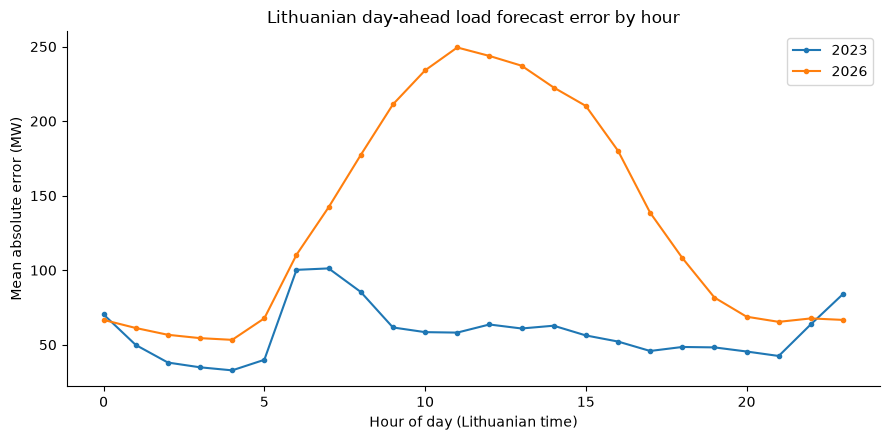

Share of hours with a forecast, % (neighbouring zones):


load_fc_mw                             wind_fc_mw                       \
year        2022   2023   2024   2025   2026       2022   2023   2024   2025   
zone                                                                           
DE_LU      100.0  100.0  100.0  100.0  100.0      100.0  100.0  100.0  100.0   
EE         100.0  100.0   99.4   99.0  100.0      100.0   99.7  100.0   99.7   
FI         100.0  100.0  100.0  100.0  100.0      100.0  100.0  100.0  100.0   
LV         100.0  100.0  100.0  100.0  100.0      100.0  100.0  100.0  100.0   
PL         100.0  100.0  100.0  100.0  100.0      100.0  100.0  100.0  100.0   
SE_3       100.0  100.0  100.0   99.7  100.0      100.0  100.0  100.0   99.2   
SE_4       100.0  100.0  100.0   99.7  100.0      100.0  100.0  100.0   99.2   

             solar_fc_mw                              
year    2026        2022   2023   2024   2025   2026  
zone                                                  
DE_LU  100.0       100.0  100.0  100.0  100.0  100.0  
EE      99.6       100.0   99.7  100.0   99.7   99.6  
FI     100.0       100.0  100.0  100.0   99.7  100.0  
LV     100.0         0.0    0.0   73.5  100.0  100.0  
PL     100.0       100.0  100.0  100.0  100.0  100.0  
SE_3    98.9       100.0  100.0  100.0   99.2   98.9  
SE_4    98.9       100.0  100.0  100.0   99.2   98.9

In [2]:
lt["year"] = lt["ts_local"].dt.year
# Describing the past accuracy of the forecasts may use the actual load to drop data errors (load_forecast_mw);
# the model inputs below use only the version cleaned with information known at the auction.
errors = pd.DataFrame({
    "load": (lt["load_forecast_mw"] - lt["load_mw"]).abs(),
    "wind": (lt["wind_forecast_mw"] - lt["wind_mw"]).abs(),
    "solar": (lt["solar_forecast_mw"] - lt["solar_mw"]).abs(),
})
mae_mw = errors.groupby(lt["year"]).mean()
actual = lt.groupby("year")[["load_mw", "wind_mw", "solar_mw"]].mean().set_axis(mae_mw.columns, axis=1)
quality = pd.concat({"MAE, MW": mae_mw, "MAE, % of actual average": 100 * mae_mw / actual}, axis=1)
display(quality.round(1))

by_hour = errors["load"].groupby([lt["year"], lt["ts_local"].dt.hour]).mean().unstack(0)
fig, ax = plt.subplots()
for year in [by_hour.columns.min(), by_hour.columns.max()]:
    ax.plot(by_hour.index, by_hour[year], marker="o", ms=3, label=str(year))
ax.set_xlabel("Hour of day (Lithuanian time)")
ax.set_ylabel("Mean absolute error (MW)")
ax.set_title("Lithuanian day-ahead load forecast error by hour")
ax.legend()
fig.tight_layout()
save(fig, "q3_load_forecast_error")
plt.show()

coverage = (zones.assign(year=zones["ts_utc"].dt.year)
                 .groupby(["zone", "year"])[["load_fc_mw", "wind_fc_mw", "solar_fc_mw"]]
                 .agg(lambda s: 100 * s.notna().mean()))
print("Share of hours with a forecast, % (neighbouring zones):")
coverage.round(1).unstack("year")

## 2. Building the data on the auction's clock

In [3]:
TZ_AUCTION = "Europe/Brussels"
ts_cet = lt["ts_utc"].dt.tz_localize("UTC").dt.tz_convert(TZ_AUCTION)
lt["day"] = ts_cet.dt.tz_localize(None).dt.normalize()
lt["hour"] = ts_cet.dt.hour
DAYS = pd.date_range(lt["day"].min() + pd.Timedelta(days=1), lt["day"].max(), freq="D")  # the first CET day is partial


hourly_index = pd.Index(lt["ts_utc"])
SERIES = ["load_fc_mw", "wind_fc_mw", "solar_fc_mw"]
wide = (zones.pivot_table(index="ts_utc", columns="zone", values=SERIES)
             .reindex(index=hourly_index,
                      columns=pd.MultiIndex.from_product([SERIES, sorted(zones["zone"].unique())])))
wide = fill_gaps(wide)

REGIONS = {"baltic": ["LV", "EE"], "nordic": ["FI", "SE_3", "SE_4"], "pl": ["PL"], "de": ["DE_LU"]}
exo_hourly = pd.DataFrame(index=hourly_index)
# the Lithuanian load forecast cleaned with information known at the auction only (sql/02_clean.sql)
lt_fc = fill_gaps(lt.set_index("ts_utc")[["load_forecast_exante_mw", "wind_forecast_mw", "solar_forecast_mw"]])
exo_hourly["lt_load"], exo_hourly["lt_wind"], exo_hourly["lt_solar"] = (lt_fc[c] for c in lt_fc.columns)
for region, members in REGIONS.items():
    solar_members = [z for z in members if z != "LV"]
    exo_hourly[f"{region}_load"] = wide["load_fc_mw"][members].sum(axis=1, min_count=len(members))
    exo_hourly[f"{region}_wind"] = wide["wind_fc_mw"][members].sum(axis=1, min_count=len(members))
    exo_hourly[f"{region}_solar"] = wide["solar_fc_mw"][solar_members].sum(axis=1, min_count=len(solar_members))

era5_hourly = pd.DataFrame({
    "lt_wind": lt["wind_cf_lt"].to_numpy(),
    "baltic_wind": lt[["wind_cf_lv", "wind_cf_ee"]].mean(axis=1).to_numpy(),
    "nordic_wind": lt[["wind_cf_fi", "wind_cf_se"]].mean(axis=1).to_numpy(),
    "pl_wind": lt["wind_cf_pl"].to_numpy(),
    "de_wind": lt["wind_cf_de"].to_numpy(),
}, index=hourly_index)


def to_days(values):
    # Hourly values (aligned with lt) -> a table of days x 24 CET hours.
    table = (pd.DataFrame({"day": lt["day"].to_numpy(), "hour": lt["hour"].to_numpy(), "v": np.asarray(values)})
               .pivot_table(index="day", columns="hour", values="v", aggfunc="mean")
               .reindex(index=DAYS, columns=range(24)))
    return table.interpolate(axis=1, limit_area="inside")


P = to_days(lt["price"])
REAL = (lt.pivot_table(index="day", columns="hour", values="price", aggfunc="count")
          .reindex(index=DAYS, columns=range(24)).fillna(0) > 0)          # hours that really exist
NEG = P < 0                                                               # negative-price hours
NEIGH = {n: to_days(lt[f"price_{n}"]) for n in ["ee", "fi", "se4", "pl"]}
EXO = {name: to_days(exo_hourly[name]) for name in exo_hourly.columns}
ERA5 = {name: to_days(era5_hourly[name]) for name in era5_hourly.columns}
ACTUAL = {name: to_days(lt[col]).fillna(EXO[name])
          for name, col in [("lt_wind", "wind_mw"), ("lt_solar", "solar_mw"), ("lt_load", "load_mw")]}


def era5_as_forecast(cf, forecast, window=90):
    # ERA5 wind of day D on the MW scale of the forecast, via a line fitted on days D-window ... D-1 only.
    ok = cf.notna() & forecast.notna()
    x, y = cf.where(ok), forecast.where(ok)
    sums = pd.DataFrame({"n": ok.sum(axis=1), "x": x.sum(axis=1), "y": y.sum(axis=1),
                         "xy": (x * y).sum(axis=1), "xx": (x * x).sum(axis=1)})
    s = sums.rolling(window, min_periods=30).sum().shift(1)            # only days before D
    slope = (s["xy"] - s["x"] * s["y"] / s["n"]) / (s["xx"] - s["x"] ** 2 / s["n"])
    intercept = (s["y"] - slope * s["x"]) / s["n"]
    return cf.mul(slope, axis=0).add(intercept, axis=0).clip(lower=0)


def with_residuals(exo):
    # Add load - wind - solar for every region that has all three.
    exo = dict(exo)
    for r in ["lt", "baltic", "nordic", "pl", "de"]:
        if all(f"{r}_{k}" in exo for k in ("load", "wind", "solar")):
            exo[f"{r}_residual"] = exo[f"{r}_load"] - exo[f"{r}_wind"] - exo[f"{r}_solar"]
    return exo


LOAD = {k: v for k, v in EXO.items() if k.endswith("_load")}
SOLAR = {k: v for k, v in EXO.items() if k.endswith("_solar")}
WIND_FC = {k: v for k, v in EXO.items() if k.endswith("_wind")}
WIND_ERA5 = {name: era5_as_forecast(ERA5[name], EXO[name]) for name in ERA5}
REALISTIC = {**LOAD, **SOLAR, **WIND_FC}
VARIANTS = {
    "no wind or solar forecasts": {**LOAD},
    "ENTSO-E forecasts": with_residuals(REALISTIC),
    "ERA5 wind (reanalysis)": with_residuals({**REALISTIC, **WIND_ERA5}),
    "actual LT wind": with_residuals({**REALISTIC, "lt_wind": ACTUAL["lt_wind"]}),
    "actual LT wind, solar and load": with_residuals({**REALISTIC, **ACTUAL}),
}
MAIN = "ENTSO-E forecasts"

cal = pd.DataFrame(index=DAYS)
cal["weekday"] = DAYS.dayofweek
lt_holidays = holidays.country_holidays("LT", years=range(DAYS.year.min(), DAYS.year.max() + 1))
cal["holiday"] = np.array([d in lt_holidays for d in DAYS.date], dtype=float)
cal["month"] = DAYS.month
cal["doy_sin"], cal["doy_cos"] = np.sin(2 * np.pi * DAYS.dayofyear / 365.25), np.cos(2 * np.pi * DAYS.dayofyear / 365.25)
gas_days = pd.merge_asof(pd.DataFrame({"cutoff": DAYS - pd.Timedelta(days=2)}),
                         gas.assign(trade_date=pd.to_datetime(gas["trade_date"])),
                         left_on="cutoff", right_on="trade_date")
cal["gas"], cal["gas_date"] = gas_days["ttf_eur_mwh"].to_numpy(), gas_days["trade_date"].to_numpy()
hydro_days = pd.merge_asof(pd.DataFrame({"cutoff": DAYS - pd.Timedelta(days=11)}),
                           hydro.assign(week_start=pd.to_datetime(hydro["week_start"])),
                           left_on="cutoff", right_on="week_start")
cal["hydro"], cal["hydro_week"] = hydro_days["deviation_gwh"].to_numpy() / 1000, hydro_days["week_start"].to_numpy()
cal["estlink2_out"] = ((DAYS >= "2024-12-25") & (DAYS < "2025-06-20")).astype(float)
print(f"{len(DAYS):,} delivery days from {DAYS[0].date()} to {DAYS[-1].date()}")

1,365 delivery days from 2023-01-01 to 2026-09-26


### 2.1 Information-set checks

In [4]:
assert (cal["gas_date"].isna() | (cal["gas_date"] <= cal.index - pd.Timedelta(days=2))).all(), "gas price from after the auction"
assert (cal["hydro_week"].isna() | (cal["hydro_week"] <= cal.index - pd.Timedelta(days=11))).all(), "hydro data not yet published"
day = TEST[0] + pd.Timedelta(days=10)
assert P.shift(1).loc[day, 7] == P.loc[day - pd.Timedelta(days=1), 7], "price lag misaligned"
# Lithuanian load forecast: cleaned with the actual load of a week earlier, never with that of the same hour
published = lt.set_index("ts_utc")["load_forecast_exante_mw"]
same_hour_only = published.notna() & lt.set_index("ts_utc")["load_forecast_mw"].isna()
assert (exo_hourly.loc[same_hour_only, "lt_load"] == published[same_hour_only]).all(), \
    "load forecast cleaned with the actual load of the same hour"
print("Gas: the latest close used is always at least two days before delivery.")
print("Hydro: the latest week used always started at least 11 days before delivery.")
print(f"Prices: the feature 'yesterday, hour 7' for {day.date()} is the price of {(day - pd.Timedelta(days=1)).date()} hour 7.")
print(f"Load forecast: {int(same_hour_only.sum())} hours that only the same-hour rule would remove are used as published.")
print("Neighbours' prices: only D-1. Actual values and ERA5 appear only in the H9 comparison variants.")

Gas: the latest close used is always at least two days before delivery.
Hydro: the latest week used always started at least 11 days before delivery.
Prices: the feature 'yesterday, hour 7' for 2026-01-11 is the price of 2026-01-10 hour 7.
Load forecast: 106 hours that only the same-hour rule would remove are used as published.
Neighbours' prices: only D-1. Actual values and ERA5 appear only in the H9 comparison variants.


## 3. The models

In [5]:
def asinh_params(values):
    # Median and robust spread of prices, for the scaled asinh transform.
    values = values[np.isfinite(values)]
    a = np.median(values)
    b = 1.4826 * np.median(np.abs(values - a))
    return a, max(b, 1.0)


def to_asinh(x, a, b):
    return np.arcsinh((x - a) / b)


def from_asinh(z, a, b):
    return a + b * np.sinh(z)


def naive_forecast():
    # Same hour yesterday on Tuesday-Friday, same hour a week ago on Monday, Saturday and Sunday.
    naive = P.shift(1).copy()
    week_ago = P.index.dayofweek.isin([0, 5, 6])
    naive.loc[week_ago] = P.shift(7).loc[week_ago]
    return naive


def lasso_design(h, exo):
    # Features of the Lasso model for delivery hour h, one row per day (residual load is left out: Lasso is linear).
    parts = [P.shift(1).add_prefix("p_d1_"), P.shift(2).add_prefix("p_d2_"), P.shift(7).add_prefix("p_d7_")]
    for n, table in NEIGH.items():
        parts += [table.shift(1)[h].rename(f"{n}_d1_h"), table.shift(1).mean(axis=1).rename(f"{n}_d1_mean")]
    for name, table in exo.items():
        if not name.endswith("_residual"):
            parts += [table[h].rename(f"{name}_h"), table.mean(axis=1).rename(f"{name}_mean")]
    parts += [cal[["gas", "hydro", "estlink2_out", "holiday", "doy_sin", "doy_cos"]],
              pd.get_dummies(cal["weekday"], prefix="wd", drop_first=True).astype(float)]
    return pd.concat(parts, axis=1)


def lgb_design(exo):
    # Features of the LightGBM model, one row per delivery day and hour.
    rows = []
    for h in range(24):
        d = pd.DataFrame(index=DAYS)
        d["hour"] = h
        d["p_d1_h"], d["p_d2_h"], d["p_d7_h"] = P.shift(1)[h], P.shift(2)[h], P.shift(7)[h]
        d["p_d1_mean"], d["p_d1_min"], d["p_d1_max"] = P.shift(1).mean(axis=1), P.shift(1).min(axis=1), P.shift(1).max(axis=1)
        for n, table in NEIGH.items():
            d[f"{n}_d1_h"], d[f"{n}_d1_mean"] = table.shift(1)[h], table.shift(1).mean(axis=1)
        for name, table in exo.items():
            d[f"{name}_h"], d[f"{name}_mean"] = table[h], table.mean(axis=1)
        d = d.join(cal[["weekday", "holiday", "month", "doy_sin", "doy_cos", "gas", "hydro", "estlink2_out"]])
        d["target"], d["real"] = P[h], REAL[h]
        rows.append(d)
    return pd.concat(rows).rename_axis("day").reset_index()


DESIGN = {}
for variant, exo in VARIANTS.items():
    lasso_x = {h: lasso_design(h, exo) for h in range(24)}
    lgb_x = lgb_design(exo)
    DESIGN[variant] = {
        "lasso": {h: x.to_numpy(dtype=float) for h, x in lasso_x.items()},
        "lasso_price_cols": np.array([c.startswith(("p_d", "ee_", "fi_", "se4_", "pl_d")) for c in lasso_x[0].columns]),
        "lgb": lgb_x,
        "lgb_features": [c for c in lgb_x.columns if c not in ("day", "target", "real")],
    }
LGB_FEATURES = DESIGN[MAIN]["lgb_features"]
P_NP = P.to_numpy()
DAY_POS = pd.Series(np.arange(len(DAYS)), index=DAYS)
CLIPS = {"model forecasts": 0, "with an input capped": 0, "with the forecast capped": 0}
print(f"Lasso: {DESIGN[MAIN]['lasso'][0].shape[1]} candidate features per hour; LightGBM: {len(LGB_FEATURES)} features")

Lasso: 122 candidate features per hour; LightGBM: 63 features


In [6]:
def lasso_aic(Z, y, n_alphas=30, max_df_share=None):
    # Lasso path by coordinate descent over 30 penalties; the one with the lowest AIC is kept.
    # max_df_share caps the number of features at that share of the observations (needed for short windows).
    z_mean, y_mean = Z.mean(axis=0), y.mean()
    Zc, yc = Z - z_mean, y - y_mean
    alpha_max = np.abs(Zc.T @ yc).max() / len(yc)
    alphas = alpha_max * np.logspace(0, -3, n_alphas)
    _, coefs, _ = lasso_path(Zc, yc, alphas=alphas)
    rss = ((yc[:, None] - Zc @ coefs) ** 2).sum(axis=0)
    df = (coefs != 0).sum(axis=0)
    aic = len(yc) * np.log(rss / len(yc)) + 2 * df
    if max_df_share is not None:
        aic = np.where(df > max_df_share * len(yc), np.inf, aic)
    coef = coefs[:, np.argmin(aic)]
    return coef, y_mean - z_mean @ coef


def fit_lasso_hour(variant, h, last_train_day, window, max_df_share=None):
    # Train the Lasso model for hour h on `window` days ending at last_train_day.
    X_all, y_all = DESIGN[variant]["lasso"][h], P_NP[:, h]
    price_cols = DESIGN[variant]["lasso_price_cols"]
    end = DAY_POS[last_train_day] + 1
    rows = np.arange(max(0, end - window), end)
    a, b = asinh_params(P_NP[rows].ravel())
    X = X_all[rows].copy()
    X[:, price_cols] = to_asinh(X[:, price_cols], a, b)
    y = to_asinh(y_all[rows], a, b)
    keep = np.isfinite(X).all(axis=1) & np.isfinite(y)
    X, y = X[keep], y[keep]
    mu, sd = X.mean(axis=0), X.std(axis=0)
    mode_share = np.array([np.unique(col, return_counts=True)[1].max() / len(col) for col in X.T])
    use = (sd > 1e-9) & (mode_share < 0.99)              # drop features that (almost) never vary in this window
    Z = np.clip((X[:, use] - mu[use]) / sd[use], -CLIP_SD, CLIP_SD)
    coef, intercept = lasso_aic(Z, y, max_df_share=max_df_share)
    return (coef, intercept), (a, b, mu, sd, use, y.min(), y.max())


def predict_lasso_hour(variant, h, model, params, days):
    a, b, mu, sd, use, y_low, y_high = params
    X = DESIGN[variant]["lasso"][h][DAY_POS[days].to_numpy()].copy()
    price_cols = DESIGN[variant]["lasso_price_cols"]
    X[:, price_cols] = to_asinh(X[:, price_cols], a, b)
    X = np.where(np.isfinite(X), X, mu)                      # a missing feature takes its training mean
    Z = (X[:, use] - mu[use]) / sd[use]
    coef, intercept = model
    z = intercept + np.clip(Z, -CLIP_SD, CLIP_SD) @ coef
    low, high = y_low - 0.5, y_high + 0.5                    # just outside the range seen in training
    CLIPS["model forecasts"] += len(z)
    CLIPS["with an input capped"] += int((np.abs(Z) > CLIP_SD).any(axis=1).sum())
    CLIPS["with the forecast capped"] += int(((z < low) | (z > high)).sum())
    return from_asinh(np.clip(z, low, high), a, b)


def lasso_block(variant, days, last_train_day, windows=None, max_df_share=None):
    # Forecast `days` with Lasso models trained up to last_train_day, averaged over the training windows.
    # One thread for the small matrix algebra: on many machines this is several times faster.
    out = np.zeros((len(days), 24))
    windows = windows or LASSO_WINDOWS
    with threadpool_limits(limits=1):
        for h in range(24):
            for window in windows:
                model, params = fit_lasso_hour(variant, h, last_train_day, window, max_df_share)
                out[:, h] += predict_lasso_hour(variant, h, model, params, days) / len(windows)
    return pd.DataFrame(out, index=days, columns=range(24))


LGB_PARAMS = dict(learning_rate=0.05, subsample=0.8, subsample_freq=1, colsample_bytree=0.8, reg_lambda=5.0,
                  random_state=SEED, deterministic=True, force_row_wise=True, verbose=-1, n_jobs=4)


def recency_weights(days, last_train_day, half_life):
    # Weight of a training day: halves every `half_life` days back from the last training day (None = equal weights).
    if half_life is None:
        return None
    return 0.5 ** ((last_train_day - days).dt.days.to_numpy() / half_life)


def fit_lgb(variant, last_train_day, params, n_estimators, half_life):
    data, features = DESIGN[variant]["lgb"], DESIGN[variant]["lgb_features"]
    train = data[(data["day"] <= last_train_day) & data["target"].notna() & data["real"]]
    a, b = asinh_params(train["target"].to_numpy())
    model = lgb.LGBMRegressor(**{**LGB_PARAMS, **params}, n_estimators=n_estimators)
    model.fit(train[features], to_asinh(train["target"].to_numpy(), a, b),
              sample_weight=recency_weights(train["day"], last_train_day, half_life))
    return model, (a, b)


def lgb_block(variant, days, last_train_day, params, n_estimators, half_life):
    model, (a, b) = fit_lgb(variant, last_train_day, params, n_estimators, half_life)
    data, features = DESIGN[variant]["lgb"], DESIGN[variant]["lgb_features"]
    rows = data[data["day"].isin(days)]
    pred = from_asinh(model.predict(rows[features]), a, b)
    table = pd.DataFrame({"day": rows["day"], "hour": rows["hour"], "pred": pred})
    return table.pivot(index="day", columns="hour", values="pred").reindex(index=days, columns=range(24)), model


def blocks(first, last, every):
    # Split the forecast period into blocks; each block is forecast by models trained up to the day before it.
    days = pd.date_range(first, last, freq="D")
    key = {"D": days, "W": days.to_period("W-SUN").start_time, "M": days.to_period("M").start_time}[every]
    for _, group in pd.Series(days, index=days).groupby(np.asarray(key)):
        yield pd.DatetimeIndex(group.to_numpy())


def walk_forward(model_name, variant, first, last, every, **kw):
    # Forecast every day from first to last, re-training every day/week/month on data before the block.
    t0, parts, last_model = time.time(), [], None
    for days in blocks(first, last, every):
        last_train_day = days[0] - pd.Timedelta(days=1)
        if model_name == "lasso":
            parts.append(lasso_block(variant, days, last_train_day))
        else:
            block, last_model = lgb_block(variant, days, last_train_day, **kw)
            parts.append(block)
    print(f"  {model_name:8s} {variant:31s} {first.date()}–{last.date()}: {time.time() - t0:5.0f} s")
    return pd.concat(parts), last_model


MODEL_CODE[:] = [asinh_params, to_asinh, from_asinh, lasso_aic, fit_lasso_hour, predict_lasso_hour, lasso_block,
                 recency_weights, fit_lgb, lgb_block, blocks, walk_forward, LGB_PARAMS, CLIP_SD]

## 4. Choosing LightGBM's settings on the validation period

In [7]:
def mae_on(pred, days, exclude=None):
    # MAE over the real hours of `days` (optionally leaving out the hours marked in `exclude`).
    mask = REAL.reindex(days)
    if exclude is not None:
        mask = mask & ~exclude.reindex(days).fillna(False)
    err = (pred.reindex(days) - P.reindex(days)).where(mask)
    return np.nanmean(np.abs(err.to_numpy()))


data = DESIGN[MAIN]["lgb"]
train = data[(data["day"] <= TRAIN_END) & data["target"].notna() & data["real"]]
valid = data[data["day"].between(*VALID) & data["target"].notna() & data["real"]]
a, b = asinh_params(train["target"].to_numpy())
valid_days = pd.date_range(*VALID, freq="D")


def try_setting(params, half_life):
    model = lgb.LGBMRegressor(**LGB_PARAMS, **params, n_estimators=3000)
    model.fit(train[LGB_FEATURES], to_asinh(train["target"].to_numpy(), a, b),
              sample_weight=recency_weights(train["day"], TRAIN_END, half_life),
              eval_set=[(valid[LGB_FEATURES], to_asinh(valid["target"].to_numpy(), a, b))],
              callbacks=[lgb.early_stopping(100, verbose=False)])
    pred = from_asinh(model.predict(valid[LGB_FEATURES]), a, b)
    return {**params, "half_life": half_life, "trees": model.best_iteration_,
            "validation MAE": np.mean(np.abs(pred - valid["target"]))}


grid = [{"objective": "regression_l1", "num_leaves": 31, "min_child_samples": 50}] if FAST else [
    {"objective": obj, "num_leaves": nl, "min_child_samples": mcs}
    for obj in ("regression", "regression_l1") for nl in (15, 31) for mcs in (50, 200)]
step1 = pd.DataFrame([try_setting(params, None) for params in grid]).sort_values("validation MAE")
best = step1.iloc[0]
best_params = {"objective": best["objective"], "num_leaves": int(best["num_leaves"]),
               "min_child_samples": int(best["min_child_samples"])}
step2 = pd.DataFrame([try_setting(best_params, hl) for hl in ([None] if FAST else [None, 365, 180])])
best2 = step2.sort_values("validation MAE").iloc[0]
LGB_SETTINGS = {"params": best_params, "n_estimators": int(best2["trees"]),
                "half_life": None if pd.isna(best2["half_life"]) else float(best2["half_life"])}
print("Chosen:", LGB_SETTINGS)
display(step1.round(2))
step2.round(2)

Chosen: {'params': {'objective': 'regression', 'num_leaves': 31, 'min_child_samples': 50}, 'n_estimators': 251, 'half_life': 180.0}


,objective,num_leaves,min_child_samples,half_life,trees,validation MAE
2,regression,31,50,None,197,29.53
3,regression,31,200,None,190,29.55
0,regression,15,50,None,241,29.61
1,regression,15,200,None,236,29.85
5,regression_l1,15,200,None,556,30.00
4,regression_l1,15,50,None,433,30.19
6,regression_l1,31,50,None,689,30.26
7,regression_l1,31,200,None,367,30.30


,objective,num_leaves,min_child_samples,half_life,trees,validation MAE
0,regression,31,50,NaN,197,29.53
1,regression,31,50,365.0,177,29.07
2,regression,31,50,180.0,251,28.81


## 5. H8 — Forecasting January–August 2026

In [8]:
t_start = time.time()
forecasts = {}
forecasts["Naive"] = naive_forecast()
first, last = VALID[0], TEST[1]
forecasts["Lasso"], _ = cached("v1_lasso", lambda: walk_forward("lasso", MAIN, first, last, LASSO_EVERY),
                               DESIGN[MAIN], LASSO_WINDOWS, LASSO_EVERY)
forecasts["LightGBM"], lgb_last_model = cached(
    "v1_lightgbm", lambda: walk_forward("lightgbm", MAIN, first, last, LGB_EVERY, **LGB_SETTINGS),
    DESIGN[MAIN], LGB_SETTINGS, LGB_EVERY)
forecasts["Ensemble"] = (forecasts["Lasso"] + forecasts["LightGBM"]) / 2
print(f"This cell took {(time.time() - t_start) / 60:.1f} minutes.")
print(f"Lasso safeguards: of {CLIPS['model forecasts']:,} model forecasts, {CLIPS['with an input capped']:,} had an input "
      f"capped at ±{CLIP_SD} SD and {CLIPS['with the forecast capped']:,} had the forecast capped.")

  v1_lasso: stored result computed 2026-10-07 09:08 at commit b85cc51 in 16.6 minutes; warnings: 16335 x ConvergenceWarning (Objective did not converge. You might want to increase the number of i)
  v1_lightgbm: stored result computed 2026-10-07 09:11 at commit b85cc51 in 2.7 minutes
This cell took 0.0 minutes.
Lasso safeguards: of 24,120 model forecasts, 1,398 had an input capped at ±5 SD and 247 had the forecast capped.


In [9]:
def scores(preds, days):
    # MAE, RMSE and MAE relative to the naive benchmark over the real hours of `days`.
    rows = {}
    for name, pred in preds.items():
        err = (pred.reindex(days) - P.reindex(days)).where(REAL.reindex(days)).to_numpy()
        rows[name] = {"MAE, €/MWh": np.nanmean(np.abs(err)), "RMSE, €/MWh": np.sqrt(np.nanmean(err ** 2))}
    table = pd.DataFrame(rows).T
    table["MAE relative to naive"] = table["MAE, €/MWh"] / table.loc["Naive", "MAE, €/MWh"]
    return table


def daily_mae_difference(pred_a, pred_b, days):
    # Daily mean absolute error of A minus that of B, over the real hours of each day (negative: A better).
    real = REAL.reindex(days)
    err_a = (pred_a.reindex(days) - P.reindex(days)).abs().where(real).mean(axis=1)
    err_b = (pred_b.reindex(days) - P.reindex(days)).abs().where(real).mean(axis=1)
    return (err_a - err_b).dropna()


def dm_test(pred_a, pred_b, days):
    # Diebold-Mariano test on daily mean absolute errors (src/backtests.py). A negative statistic means A is more accurate.
    d = daily_mae_difference(pred_a, pred_b, days)
    statistic, p_value = diebold_mariano(d.to_numpy(), max_lags=7)
    return pd.Series({"difference in MAE, €/MWh": d.mean(), "DM statistic": statistic, "p_value": p_value})


test_days = pd.date_range(*TEST, freq="D")
test_scores = scores(forecasts, test_days)
display(test_scores.round(3))

dm = pd.DataFrame({
    "Ensemble vs Naive": dm_test(forecasts["Ensemble"], forecasts["Naive"], test_days),
    "Ensemble vs Lasso": dm_test(forecasts["Ensemble"], forecasts["Lasso"], test_days),
    "Ensemble vs LightGBM": dm_test(forecasts["Ensemble"], forecasts["LightGBM"], test_days),
    "Lasso vs Naive": dm_test(forecasts["Lasso"], forecasts["Naive"], test_days),
    "LightGBM vs Naive": dm_test(forecasts["LightGBM"], forecasts["Naive"], test_days),
}).T
show_p(dm.round(3))

,"MAE, €/MWh","RMSE, €/MWh",MAE relative to naive
Naive,41.799,61.270,1.000
Lasso,27.503,39.564,0.658
LightGBM,25.560,37.544,0.611
Ensemble,24.770,36.105,0.593


,"difference in MAE, €/MWh",DM statistic,p_value
Ensemble vs Naive,-17.032,-9.784,<0.001
Ensemble vs Lasso,-2.733,-5.727,<0.001
Ensemble vs LightGBM,-0.791,-1.889,0.059
Lasso vs Naive,-14.298,-8.643,<0.001
LightGBM vs Naive,-16.241,-8.684,<0.001


### 5.1 In sample against out of sample

In [10]:
in_days = pd.date_range(TRAIN_END - pd.Timedelta(days=181), TRAIN_END, freq="D")
with count_warnings() as in_sample_warnings:
    in_sample = {"Naive": forecasts["Naive"], "Lasso": lasso_block(MAIN, in_days, TRAIN_END)}
    in_sample["LightGBM"], _ = lgb_block(MAIN, in_days, TRAIN_END, **LGB_SETTINGS)
print("In-sample fits" + (describe_warnings(in_sample_warnings) or ": no warnings"))
in_sample["Ensemble"] = (in_sample["Lasso"] + in_sample["LightGBM"]) / 2
overfit = pd.DataFrame({
    "in sample (Apr–Sep 2025)": scores(in_sample, in_days)["MAE, €/MWh"],
    "validation (Oct–Dec 2025)": scores(forecasts, valid_days)["MAE, €/MWh"],
    "test (Jan–Aug 2026)": test_scores["MAE, €/MWh"],
})
overfit.round(2)

In-sample fits; warnings: 64 x ConvergenceWarning (Objective did not converge. You might want to increase the number of i)


,in sample (Apr–Sep 2025),validation (Oct–Dec 2025),test (Jan–Aug 2026)
Naive,34.42,55.06,41.80
Lasso,17.86,30.97,27.50
LightGBM,11.28,28.81,25.56
Ensemble,13.58,28.25,24.77


### 5.2 Where the errors are

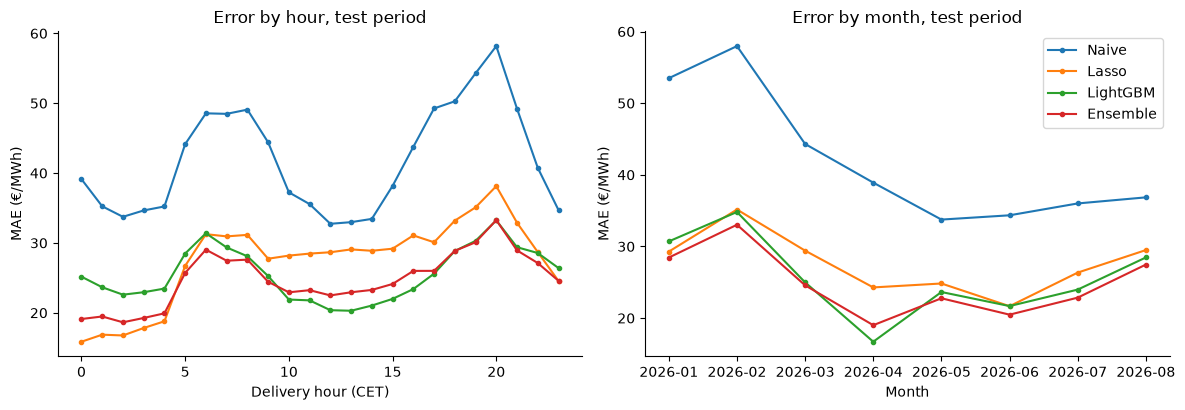

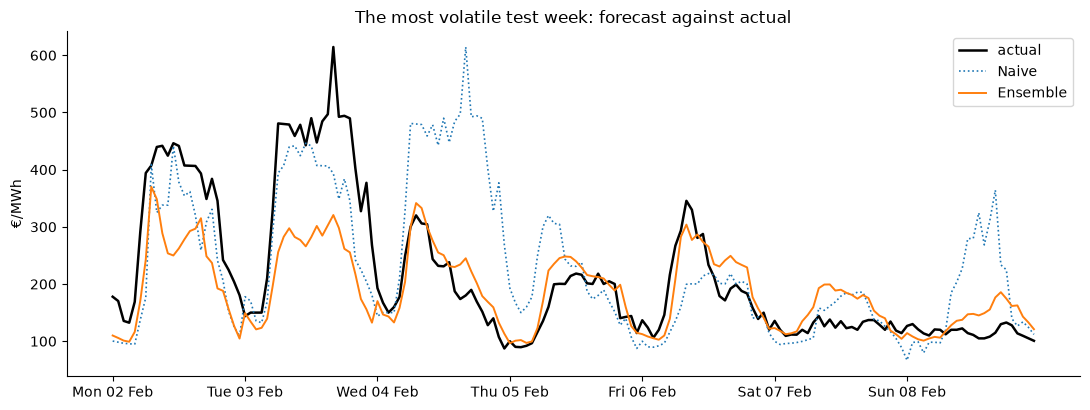

In [11]:
def mae_by(pred, days, key):
    real = REAL.reindex(days)
    err = (pred.reindex(days) - P.reindex(days)).abs().where(real)
    if key == "hour":
        return err.mean(axis=0)
    daily = err.mean(axis=1)
    return daily.groupby(daily.index.to_period("M")).mean()


fig, axes = plt.subplots(1, 2, figsize=(12, 4.2))
for name in ["Naive", "Lasso", "LightGBM", "Ensemble"]:
    axes[0].plot(range(24), mae_by(forecasts[name], test_days, "hour"), marker="o", ms=3, label=name)
    monthly = mae_by(forecasts[name], test_days, "month")
    axes[1].plot(monthly.index.astype(str), monthly.to_numpy(), marker="o", ms=3, label=name)
axes[0].set(xlabel="Delivery hour (CET)", ylabel="MAE (€/MWh)", title="Error by hour, test period")
axes[1].set(xlabel="Month", ylabel="MAE (€/MWh)", title="Error by month, test period")
axes[1].legend()
fig.tight_layout()
save(fig, "q3_error_by_hour_month")
plt.show()

# the test week with the largest price swings
test_prices = P.reindex(test_days).where(REAL.reindex(test_days))
weekly_spread = test_prices.groupby(test_days.to_period("W-SUN")).apply(lambda g: np.nanstd(g.to_numpy()))
week = weekly_spread.idxmax()
week_days = pd.date_range(week.start_time, week.end_time.normalize(), freq="D")
fig, ax = plt.subplots(figsize=(11, 4.2))
for name, style in [("actual", dict(color="black", lw=1.8)), ("Naive", dict(ls=":", lw=1.2)),
                    ("Ensemble", dict(lw=1.4))]:
    table = P if name == "actual" else forecasts[name]
    series = table.reindex(week_days).where(REAL.reindex(week_days)).to_numpy().ravel()
    ax.plot(range(len(series)), series, label=name, **style)
ax.set_xticks(range(0, 24 * len(week_days), 24), [d.strftime("%a %d %b") for d in week_days])
ax.set_ylabel("€/MWh")
ax.set_title("The most volatile test week: forecast against actual")
ax.legend()
fig.tight_layout()
save(fig, "q3_example_week")
plt.show()

### 5.3 What drives the LightGBM forecast

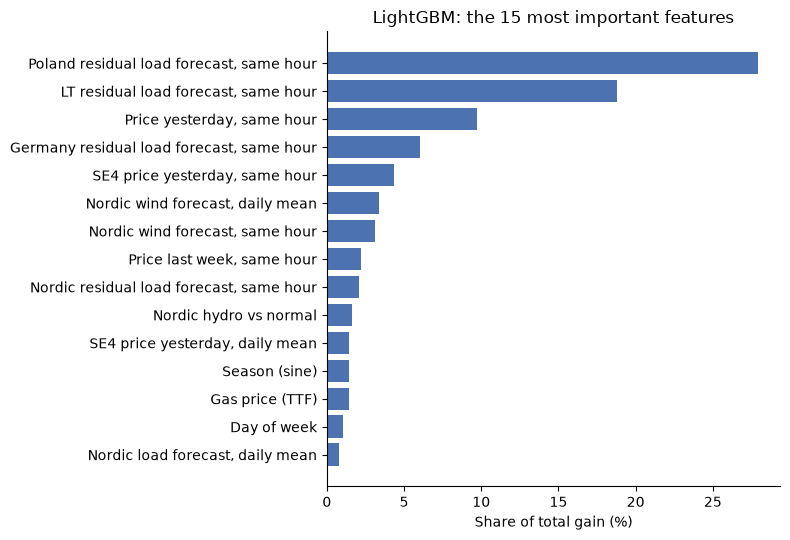

In [12]:
REGION_NAMES = {"lt": "LT", "baltic": "Baltic", "nordic": "Nordic", "pl": "Poland", "de": "Germany"}
KINDS = {"load": "load forecast", "wind": "wind forecast", "solar": "solar forecast", "residual": "residual load forecast"}
PRICE_NAMES = {"ee": "Estonian", "fi": "Finnish", "se4": "SE4", "pl": "Polish"}
SIMPLE = {"p_d1_h": "Price yesterday, same hour", "p_d2_h": "Price 2 days ago, same hour",
          "p_d7_h": "Price last week, same hour", "p_d1_mean": "Price yesterday, daily mean",
          "p_d1_min": "Price yesterday, daily minimum", "p_d1_max": "Price yesterday, daily maximum",
          "hour": "Hour of day", "weekday": "Day of week", "holiday": "Holiday", "month": "Month",
          "doy_sin": "Season (sine)", "doy_cos": "Season (cosine)", "gas": "Gas price (TTF)",
          "hydro": "Nordic hydro vs normal", "estlink2_out": "Estlink 2 outage", "eua": "Carbon price proxy (EUA)"}


def readable(name):
    # A plain-English label for a feature name.
    if name in SIMPLE:
        return SIMPLE[name]
    if name.startswith("ntc_"):
        core, suffix = name[4:].rsplit("_", 1)
        origin, destination = core.split("_to_")
        return (f"Capacity {origin.upper().replace('_', '')} → {destination.upper().replace('_', '')}, "
                + ("same hour" if suffix == "h" else "daily mean"))
    head, *rest = name.split("_")
    if head in PRICE_NAMES and rest[0] == "d1":
        return f"{PRICE_NAMES[head]} price yesterday, " + ("same hour" if rest[1] == "h" else "daily mean")
    if head in REGION_NAMES and rest and rest[0] in KINDS:
        label, tail = f"{REGION_NAMES[head]} {KINDS[rest[0]]}", rest[1:]
        for key, words in [("d1", " for yesterday"), ("chg", ", change from yesterday"), ("sq", ", squared")]:
            if tail[:1] == [key]:
                label, tail = label + words, tail[1:]
        return label + {"h": ", same hour", "mean": ", daily mean"}.get(tail[0] if tail else "", "")
    return name


importance = (pd.Series(lgb_last_model.booster_.feature_importance("gain"), index=LGB_FEATURES)
                .sort_values(ascending=False))
top = (100 * importance / importance.sum()).head(15)
fig, ax = plt.subplots(figsize=(8, 5.5))
ax.barh([readable(n) for n in top.index[::-1]], top.to_numpy()[::-1], color="#4c72b0")
ax.set_xlabel("Share of total gain (%)")
ax.set_title("LightGBM: the 15 most important features")
fig.tight_layout()
save(fig, "q3_feature_importance")
plt.show()

## 6. H9 — How much would better information be worth?

In [13]:
h9_every = "M"  # monthly re-training keeps this comparison to a few minutes
h9 = {}
for i, variant in enumerate(VARIANTS):
    lasso_pred = cached(f"h9_lasso_{i}", lambda: pd.concat([lasso_block(variant, days, days[0] - pd.Timedelta(days=1))
                                                          for days in blocks(*TEST, h9_every)]),
                        DESIGN[variant], LASSO_WINDOWS, h9_every)
    lgb_pred, _ = cached(f"h9_lightgbm_{i}", lambda: walk_forward("lightgbm", variant, *TEST, h9_every, **LGB_SETTINGS),
                         DESIGN[variant], LGB_SETTINGS, h9_every)
    h9[variant] = {"Lasso": lasso_pred, "LightGBM": lgb_pred, "Ensemble": (lasso_pred + lgb_pred) / 2}

h9_mae = pd.DataFrame({
    v: {**{m: mae_on(p, test_days) for m, p in models.items()},
        "Ensemble, without negative-price hours": mae_on(models["Ensemble"], test_days, exclude=NEG)}
    for v, models in h9.items()
}).T
h9_dm = pd.DataFrame({
    f"{v} vs ENTSO-E forecasts": dm_test(h9[v]["Ensemble"], h9[MAIN]["Ensemble"], test_days)
    for v in VARIANTS if v != MAIN
}).T
display(h9_mae.round(2))
show_p(h9_dm.round(3))

  h9_lasso_0: stored result computed 2026-10-07 09:12 at commit b85cc51 in 0.4 minutes; warnings: 565 x ConvergenceWarning (Objective did not converge. You might want to increase the number of i)
  h9_lightgbm_0: stored result computed 2026-10-07 09:12 at commit b85cc51 in 0.3 minutes
  h9_lasso_1: stored result computed 2026-10-07 09:12 at commit b85cc51 in 0.4 minutes; warnings: 388 x ConvergenceWarning (Objective did not converge. You might want to increase the number of i)
  h9_lightgbm_1: stored result computed 2026-10-07 09:13 at commit b85cc51 in 0.5 minutes
  h9_lasso_2: stored result computed 2026-10-07 09:13 at commit b85cc51 in 0.5 minutes; warnings: 432 x ConvergenceWarning (Objective did not converge. You might want to increase the number of i)
  h9_lightgbm_2: stored result computed 2026-10-07 09:14 at commit b85cc51 in 0.5 minutes
  h9_lasso_3: stored result computed 2026-10-07 09:14 at commit b85cc51 in 0.4 minutes; warnings: 388 x ConvergenceWarning (Objective did not 

,Lasso,LightGBM,Ensemble,"Ensemble, without negative-price hours"
no wind or solar forecasts,31.65,33.14,30.23,30.35
ENTSO-E forecasts,30.62,27.00,26.89,26.87
ERA5 wind (reanalysis),31.65,28.89,28.27,28.25
actual LT wind,31.75,28.24,27.98,27.99
"actual LT wind, solar and load",31.53,28.05,27.74,27.76


,"difference in MAE, €/MWh",DM statistic,p_value
no wind or solar forecasts vs ENTSO-E forecasts,3.335,3.993,<0.001
ERA5 wind (reanalysis) vs ENTSO-E forecasts,1.374,3.373,0.001
actual LT wind vs ENTSO-E forecasts,1.091,2.943,0.003
"actual LT wind, solar and load vs ENTSO-E forecasts",0.844,2.310,0.021


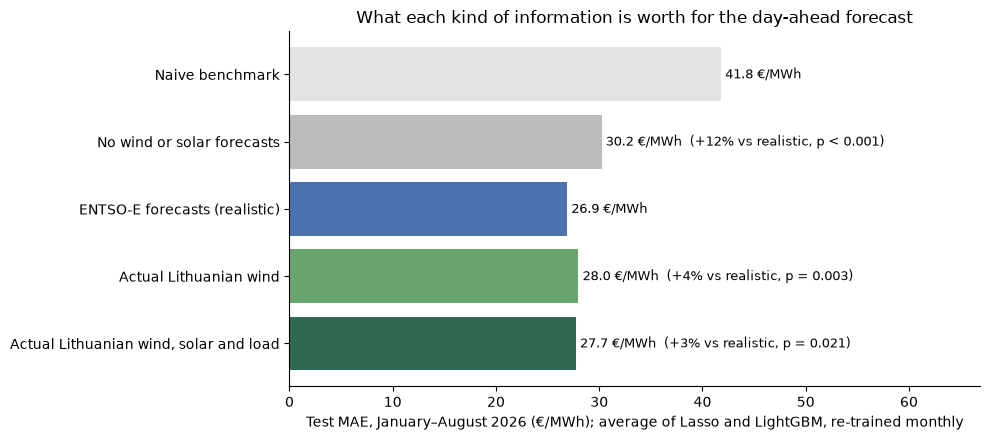

In [14]:
order = ["no wind or solar forecasts", "ENTSO-E forecasts", "actual LT wind", "actual LT wind, solar and load"]
labels = ["Naive benchmark", "No wind or solar forecasts", "ENTSO-E forecasts (realistic)",
          "Actual Lithuanian wind", "Actual Lithuanian wind, solar and load"]
naive_mae = test_scores.loc["Naive", "MAE, €/MWh"]
values = [naive_mae] + list(h9_mae.loc[order, "Ensemble"])
base = h9_mae.loc[MAIN, "Ensemble"]

fig, ax = plt.subplots(figsize=(10, 4.5))
ax.barh(range(len(values)), values, color=["#e3e3e3", "#bbbbbb", "#4c72b0", "#6aa56e", "#2d6a4f"])
for i, v in enumerate(values):
    name = None if i == 0 else order[i - 1]
    if name in (None, MAIN):
        text = f"{v:.1f} €/MWh"
    else:
        p_value = h9_dm.loc[f"{name} vs ENTSO-E forecasts", "p_value"]
        text = f"{v:.1f} €/MWh  ({100 * (v / base - 1):+.0f}% vs realistic, {fmt_p(p_value)})"
    ax.text(v + 0.4, i, text, va="center", fontsize=9)
ax.set_yticks(range(len(values)), labels)
ax.invert_yaxis()
ax.set_xlim(0, max(values) * 1.6)
ax.set_xlabel("Test MAE, January–August 2026 (€/MWh); average of Lasso and LightGBM, re-trained monthly")
ax.set_title("What each kind of information is worth for the day-ahead forecast")
fig.tight_layout()
save(fig, "q3_h9_information_value")
plt.show()

### 6.1 How much of the price error comes from Lithuanian forecast errors?

In [15]:
def flat(table, days):
    return table.reindex(days).where(REAL.reindex(days)).to_numpy().ravel()


att = pd.DataFrame({
    "price_error": flat(forecasts["Ensemble"] - P, test_days),
    "wind_error": flat((EXO["lt_wind"] - ACTUAL["lt_wind"]) / 100, test_days),
    "solar_error": flat((EXO["lt_solar"] - ACTUAL["lt_solar"]) / 100, test_days),
    "load_error": flat((EXO["lt_load"] - ACTUAL["lt_load"]) / 100, test_days),
}).dropna()
m_att = sm.OLS(att["price_error"], sm.add_constant(att[["wind_error", "solar_error", "load_error"]])).fit(
    cov_type="HAC", cov_kwds={"maxlags": 24})
attribution = pd.DataFrame({
    "€/MWh per 100 MW forecast error": m_att.params, "ci_low": m_att.conf_int()[0],
    "ci_high": m_att.conf_int()[1], "p_value": m_att.pvalues,
}).drop("const")
print(f"Lithuanian forecast errors explain {100 * m_att.rsquared:.1f}% of the variance of the price forecast error.")

daily = pd.DataFrame({
    "price MAE": (forecasts["Ensemble"] - P).abs().where(REAL).reindex(test_days).mean(axis=1),
    "wind error": (EXO["lt_wind"] - ACTUAL["lt_wind"]).abs().reindex(test_days).mean(axis=1),
})
daily["wind forecast error"] = pd.qcut(daily["wind error"].rank(method="first"), 5,
                                      labels=["smallest 20%", "2", "3", "4", "largest 20%"])
display(daily.groupby("wind forecast error", observed=True)[["wind error", "price MAE"]].mean()
             .rename(columns={"wind error": "mean wind forecast error, MW", "price MAE": "price MAE, €/MWh"}).round(1))
show_p(attribution.round(3))

Lithuanian forecast errors explain 0.1% of the variance of the price forecast error.


,"mean wind forecast error, MW","price MAE, €/MWh"
wind forecast error,,
smallest 20%,55.8,24.2
2,86.3,24.8
3,115.3,23.0
4,164.7,21.9
largest 20%,302.1,29.9


,€/MWh per 100 MW forecast error,ci_low,ci_high,p_value
wind_error,-0.245,-1.566,1.076,0.716
solar_error,-0.783,-2.115,0.548,0.249
load_error,0.260,-0.975,1.494,0.680


## 7. Summary of H8–H9

In [16]:
h8 = dm.loc["Ensemble vs Naive"]
h8_ok = h8["difference in MAE, €/MWh"] < 0 and h8["p_value"] < 0.05
h9_test = h9_dm.loc["actual LT wind vs ENTSO-E forecasts"]
h9_ok = h9_test["difference in MAE, €/MWh"] < 0 and h9_test["p_value"] < 0.05
def change(new, old):
    # "12% lower" or "3% higher": the relative change from old to new.
    pct = 100 * (new / old - 1)
    return f"{abs(pct):.0f}% {'higher' if pct > 0 else 'lower'}"


summary = pd.DataFrame([
    ["H8", "The model beats the naive benchmark",
     f"ensemble MAE {test_scores.loc['Ensemble', 'MAE, €/MWh']:.2f} vs naive {test_scores.loc['Naive', 'MAE, €/MWh']:.2f} €/MWh "
     f"({change(test_scores.loc['Ensemble', 'MAE, €/MWh'], test_scores.loc['Naive', 'MAE, €/MWh'])}, DM {fmt_p(h8['p_value'])})",
     "supported" if h8_ok else "not supported"],
    ["H9", "Knowing the actual Lithuanian wind output makes the forecast significantly more accurate",
     f"ensemble MAE {h9_mae.loc['actual LT wind', 'Ensemble']:.2f} vs {h9_mae.loc[MAIN, 'Ensemble']:.2f} €/MWh "
     f"({change(h9_mae.loc['actual LT wind', 'Ensemble'], h9_mae.loc[MAIN, 'Ensemble'])}, DM {fmt_p(h9_test['p_value'])}; "
     f"{change(h9_mae.loc['actual LT wind', 'Ensemble, without negative-price hours'], h9_mae.loc[MAIN, 'Ensemble, without negative-price hours'])} "
     "without negative-price hours)",
     "supported" if h9_ok else "not supported"],
], columns=["hypothesis", "statement", "estimate", "verdict"])
summary.to_csv(FIG / "q3_summary.csv", index=False)
display(summary)

top_feature = readable(importance.index[0])
extra = pd.DataFrame([
    ["Ensemble vs LightGBM alone", f"{dm.loc['Ensemble vs LightGBM', 'difference in MAE, €/MWh']:+.2f} €/MWh "
                                   f"({fmt_p(dm.loc['Ensemble vs LightGBM', 'p_value'])})"],
    ["Re-training monthly instead of daily/weekly (ENTSO-E set)",
     f"MAE {h9_mae.loc[MAIN, 'Ensemble']:.1f} vs {test_scores.loc['Ensemble', 'MAE, €/MWh']:.1f} €/MWh "
     f"({change(h9_mae.loc[MAIN, 'Ensemble'], test_scores.loc['Ensemble', 'MAE, €/MWh'])})"],
    ["ERA5 reanalysis wind instead of the operators' forecasts",
     f"MAE {h9_mae.loc['ERA5 wind (reanalysis)', 'Ensemble']:.1f} vs {h9_mae.loc[MAIN, 'Ensemble']:.1f} €/MWh "
     f"({fmt_p(h9_dm.loc['ERA5 wind (reanalysis) vs ENTSO-E forecasts', 'p_value'])})"],
    ["Share of the price error explained by Lithuanian forecast errors", f"{100 * m_att.rsquared:.1f}%"],
    ["Most important LightGBM feature", f"{top_feature} ({top.iloc[0]:.0f}% of total gain)"],
], columns=["additional finding", "estimate"])
extra.to_csv(FIG / "q3_followup.csv", index=False)
extra

,hypothesis,statement,estimate,verdict
0,H8,The model beats the naive benchmark,ensemble MAE 24.77 vs naive 41.80 €/MWh (41% l...,supported
1,H9,Knowing the actual Lithuanian wind output make...,"ensemble MAE 27.98 vs 26.89 €/MWh (4% higher, ...",not supported


,additional finding,estimate
0,Ensemble vs LightGBM alone,-0.79 €/MWh (p = 0.059)
1,Re-training monthly instead of daily/weekly (E...,MAE 26.9 vs 24.8 €/MWh (9% higher)
2,ERA5 reanalysis wind instead of the operators'...,MAE 28.3 vs 26.9 €/MWh (p < 0.001)
3,Share of the price error explained by Lithuani...,0.1%
4,Most important LightGBM feature,"Poland residual load forecast, same hour (28% ..."


## 8. An improved model (v2)

In [17]:
FRESH = (TEST[1] + pd.Timedelta(days=1), DAYS[-1])
HAS_FRESH = (FRESH[1] - FRESH[0]).days >= 6
print(f"Fresh test period: {FRESH[0].date()} – {FRESH[1].date()}" if HAS_FRESH
      else "No data after August 2026: download it to run the fresh test (see the README).")


def rolling_line(x, y, window=56, lag=2):
    # For every day D: slope and intercept of y on x over the `window` days that end at D-lag (all hours pooled).
    ok = x.notna() & y.notna()
    xs, ys = x.where(ok), y.where(ok)
    sums = pd.DataFrame({"n": ok.sum(axis=1), "x": xs.sum(axis=1), "y": ys.sum(axis=1),
                         "xy": (xs * ys).sum(axis=1), "xx": (xs * xs).sum(axis=1)})
    s = sums.rolling(window, min_periods=28).sum().shift(lag)
    slope = (s["xy"] - s["x"] * s["y"] / s["n"]) / (s["xx"] - s["x"] ** 2 / s["n"])
    return slope, (s["y"] - slope * s["x"]) / s["n"]


# 1) the Lithuanian load forecast corrected for rooftop solar: its error is explained by the solar forecast,
#    with a line fitted on days D-57 ... D-2 (the actual load of D-1 is not complete at the auction)
load_error = EXO["lt_load"] - to_days(lt["load_mw"])
slope, intercept = rolling_line(EXO["lt_solar"], load_error)
LT_LOAD_CORRECTED = EXO["lt_load"] - EXO["lt_solar"].mul(slope.fillna(0), axis=0).add(intercept.fillna(0), axis=0)
actual_load = to_days(lt["load_mw"])
def mae_by_year(forecast):
    # Mean absolute error over the real hours of each year.
    err = (forecast - actual_load).abs().where(REAL)
    return pd.Series({y: np.nanmean(err[DAYS.year == y].to_numpy()) for y in sorted(set(DAYS.year))})


check = pd.DataFrame({"forecast as published": mae_by_year(EXO["lt_load"]),
                      "corrected for rooftop solar": mae_by_year(LT_LOAD_CORRECTED)})
print("Lithuanian load forecast, mean absolute error (MW):")
display(check.round(1))

# 2) day-ahead cross-border capacities: every border with a value in at least 90% of the hours
NTC = {}
if len(ntc):
    ntc_wide = fill_gaps(ntc.pivot_table(index="ts_utc", columns="border", values="mw").reindex(hourly_index))
    ntc_cover = {}
    for border in ntc_wide.columns:
        table = to_days(ntc_wide[border])
        ntc_cover[border] = 100 * table.notna().to_numpy().mean()
        if ntc_cover[border] >= 90:
            NTC[f"ntc_{border.replace('-', '_to_').lower()}"] = table
    print("Share of hours with a day-ahead capacity, %:", {k: round(v, 1) for k, v in ntc_cover.items()})
print("Capacities used:", [readable(f"{n}_h") for n in NTC] or "none")

# 3) the carbon price proxy: the close of D-2, like gas
if len(eua):
    eua_days = pd.merge_asof(pd.DataFrame({"cutoff": DAYS - pd.Timedelta(days=2)}),
                             eua.assign(trade_date=pd.to_datetime(eua["trade_date"])),
                             left_on="cutoff", right_on="trade_date")
    cal["eua"] = eua_days["eua_proxy"].to_numpy()
DAILY_V2 = ["gas", "hydro", "estlink2_out", "holiday", "doy_sin", "doy_cos"] + (["eua"] if "eua" in cal else [])

Fresh test period: 2026-09-01 – 2026-09-26
Lithuanian load forecast, mean absolute error (MW):


,forecast as published,corrected for rooftop solar
2023,58.6,58.5
2024,73.7,77.3
2025,84.4,75.6
2026,135.5,93.1


Share of hours with a day-ahead capacity, %: {'EE-FI': np.float64(100.0), 'EE-LV': np.float64(100.0), 'FI-EE': np.float64(100.0), 'LT-LV': np.float64(100.0), 'LT-PL': np.float64(100.0), 'LT-SE_4': np.float64(99.2), 'LV-EE': np.float64(100.0), 'LV-LT': np.float64(100.0), 'PL-LT': np.float64(100.0), 'SE_4-LT': np.float64(99.2)}
Capacities used: ['Capacity EE → FI, same hour', 'Capacity EE → LV, same hour', 'Capacity FI → EE, same hour', 'Capacity LT → LV, same hour', 'Capacity LT → PL, same hour', 'Capacity LT → SE4, same hour', 'Capacity LV → EE, same hour', 'Capacity LV → LT, same hour', 'Capacity PL → LT, same hour', 'Capacity SE4 → LT, same hour']


In [18]:
EXO_V2 = with_residuals({**REALISTIC, "lt_load": LT_LOAD_CORRECTED})
RESIDUAL_REGIONS = [r for r in ["lt", "baltic", "nordic", "pl", "de"] if f"{r}_residual" in EXO_V2]


def lasso_design_v2(h):
    # v1 features (with the corrected LT load) plus residual load, its square and its change from yesterday for
    # Lithuania and Poland, and the cross-border capacities for hour h.
    parts = [P.shift(1).add_prefix("p_d1_"), P.shift(2).add_prefix("p_d2_"), P.shift(7).add_prefix("p_d7_")]
    for n, table in NEIGH.items():
        parts += [table.shift(1)[h].rename(f"{n}_d1_h"), table.shift(1).mean(axis=1).rename(f"{n}_d1_mean")]
    for name, table in EXO_V2.items():
        if not name.endswith("_residual"):
            parts += [table[h].rename(f"{name}_h"), table.mean(axis=1).rename(f"{name}_mean")]
    for r in ["lt", "pl"]:
        res = EXO_V2[f"{r}_residual"]
        parts += [res[h].rename(f"{r}_residual_h"), (res[h] ** 2).rename(f"{r}_residual_sq_h"),
                  (res[h] - res.shift(1)[h]).rename(f"{r}_residual_chg_h")]
    for name, table in NTC.items():
        parts.append(table[h].rename(f"{name}_h"))
    parts += [cal[DAILY_V2], pd.get_dummies(cal["weekday"], prefix="wd", drop_first=True).astype(float)]
    return pd.concat(parts, axis=1)


def lgb_design_v2():
    # v1 features (with the corrected LT load) plus yesterday's forecasts (published on D-2), the change in
    # residual load from yesterday, cross-border capacities and the carbon price proxy.
    rows = []
    for h in range(24):
        cols = {"hour": pd.Series(h, index=DAYS),
                "p_d1_h": P.shift(1)[h], "p_d2_h": P.shift(2)[h], "p_d7_h": P.shift(7)[h],
                "p_d1_mean": P.shift(1).mean(axis=1), "p_d1_min": P.shift(1).min(axis=1),
                "p_d1_max": P.shift(1).max(axis=1)}
        for n, table in NEIGH.items():
            cols[f"{n}_d1_h"], cols[f"{n}_d1_mean"] = table.shift(1)[h], table.shift(1).mean(axis=1)
        for name, table in EXO_V2.items():
            cols[f"{name}_h"], cols[f"{name}_mean"], cols[f"{name}_d1_h"] = table[h], table.mean(axis=1), table.shift(1)[h]
        for r in RESIDUAL_REGIONS:
            cols[f"{r}_residual_chg_h"] = EXO_V2[f"{r}_residual"][h] - EXO_V2[f"{r}_residual"].shift(1)[h]
        for name, table in NTC.items():
            cols[f"{name}_h"], cols[f"{name}_mean"] = table[h], table.mean(axis=1)
        for c in ["weekday", "month"] + DAILY_V2:
            cols[c] = cal[c]
        cols["target"], cols["real"] = P[h], REAL[h]
        rows.append(pd.DataFrame(cols, index=DAYS))    # built at once: much faster than adding columns one by one
    return pd.concat(rows).rename_axis("day").reset_index()


lasso_v2_x = {h: lasso_design_v2(h) for h in range(24)}
lgb_v2_x = lgb_design_v2()
DESIGN["v2"] = {
    "lasso": {h: x.to_numpy(dtype=float) for h, x in lasso_v2_x.items()},
    "lasso_price_cols": np.array([c.startswith(("p_d", "ee_", "fi_", "se4_", "pl_d")) for c in lasso_v2_x[0].columns]),
    "lgb": lgb_v2_x,
    "lgb_features": [c for c in lgb_v2_x.columns if c not in ("day", "target", "real")],
}
print(f"v2 Lasso: {DESIGN['v2']['lasso'][0].shape[1]} candidate features per hour; "
      f"v2 LightGBM: {len(DESIGN['v2']['lgb_features'])} features")

v2 Lasso: 139 candidate features per hour; v2 LightGBM: 109 features


### 8.1 Choices on the validation period

In [19]:
W_V2 = [84] if FAST else [56, 84, 364, 728]
LASSO_CONFIGS = {  # name -> (design, training windows, cap on model size)
    "v1 (fixed in advance)": (MAIN, LASSO_WINDOWS, None),
    "v2 inputs, windows " + "/".join(map(str, LASSO_WINDOWS)): ("v2", LASSO_WINDOWS, None),
    "v2 inputs, windows " + "/".join(map(str, W_V2)): ("v2", W_V2, 1 / 3),
}


def run_lasso(config, first, last):
    design, windows, share = LASSO_CONFIGS[config]
    return pd.concat([lasso_block(design, days, days[0] - pd.Timedelta(days=1), windows=windows, max_df_share=share)
                      for days in blocks(first, last, LASSO_EVERY)])


lasso_val = {"v1 (fixed in advance)": forecasts["Lasso"]}
for i, config in enumerate(list(LASSO_CONFIGS)[1:]):
    lasso_val[config] = cached(f"v2_lasso_validation_{i}", lambda: run_lasso(config, *VALID),
                               run_lasso, DESIGN[LASSO_CONFIGS[config][0]], LASSO_CONFIGS[config], LASSO_EVERY)

# LightGBM v2: the tree settings chosen in section 4, learning rate 0.1, trees chosen by early stopping per half-life
HALF_LIVES = [365] if FAST else [180, 365]
V2_PARAMS = {**LGB_SETTINGS["params"], "learning_rate": 0.1}
data2, feats2 = DESIGN["v2"]["lgb"], DESIGN["v2"]["lgb_features"]
train2 = data2[(data2["day"] <= TRAIN_END) & data2["target"].notna() & data2["real"]]
valid2 = data2[data2["day"].between(*VALID) & data2["target"].notna() & data2["real"]]
a2, b2 = asinh_params(train2["target"].to_numpy())
V2_TREES = {}
for hl in HALF_LIVES:
    model = lgb.LGBMRegressor(**{**LGB_PARAMS, **V2_PARAMS}, n_estimators=2000)
    model.fit(train2[feats2], to_asinh(train2["target"].to_numpy(), a2, b2),
              sample_weight=recency_weights(train2["day"], TRAIN_END, hl),
              eval_set=[(valid2[feats2], to_asinh(valid2["target"].to_numpy(), a2, b2))],
              callbacks=[lgb.early_stopping(100, verbose=False)])
    V2_TREES[hl] = max(model.best_iteration_, 50)
print("v2 LightGBM trees per half-life:", V2_TREES)


def lgb_v2_block(days, last_train_day):
    # Average of the LightGBM models with the different half-lives.
    preds = [lgb_block("v2", days, last_train_day, V2_PARAMS, V2_TREES[hl], hl)[0] for hl in HALF_LIVES]
    return sum(preds) / len(preds)


def run_lgb_v2(first, last, every):
    return pd.concat([lgb_v2_block(days, days[0] - pd.Timedelta(days=1)) for days in blocks(first, last, every)])


# in validation both LightGBM versions are re-trained weekly, so they compare like with like
lgb_val = {"v1 (fixed in advance)": forecasts["LightGBM"],
           "v2 inputs, averaged half-lives": cached("v2_lgb_validation", lambda: run_lgb_v2(*VALID, LGB_EVERY),
                                                     run_lgb_v2, lgb_v2_block, DESIGN["v2"], V2_PARAMS,
                                                     V2_TREES, HALF_LIVES, LGB_EVERY)}

choice = pd.DataFrame({
    "validation MAE, €/MWh": {**{f"Lasso: {k}": mae_on(v, valid_days) for k, v in lasso_val.items()},
                              **{f"LightGBM: {k}": mae_on(v, valid_days) for k, v in lgb_val.items()}}})
LASSO_CHOICE = min(lasso_val, key=lambda k: mae_on(lasso_val[k], valid_days))
LGB_CHOICE = min(lgb_val, key=lambda k: mae_on(lgb_val[k], valid_days))
print(f"Chosen for v2 -> Lasso: {LASSO_CHOICE}; LightGBM: {LGB_CHOICE}")

# hour-specific weight of LightGBM: the inverse of each model's validation error in that hour, normalised
err_lasso = (lasso_val[LASSO_CHOICE] - P).abs().where(REAL).reindex(valid_days).mean(axis=0)
err_lgb = (lgb_val[LGB_CHOICE] - P).abs().where(REAL).reindex(valid_days).mean(axis=0)
W_LGB = (1 / err_lgb) / (1 / err_lgb + 1 / err_lasso)
print("Weight of LightGBM by delivery hour (CET):", W_LGB.round(2).to_dict())
choice.round(2)

  v2_lasso_validation_0: stored result computed 2026-10-07 09:24 at commit b85cc51 in 8.5 minutes; warnings: 6845 x ConvergenceWarning (Objective did not converge. You might want to increase the number of i)
  v2_lasso_validation_1: stored result computed 2026-10-07 09:35 at commit b85cc51 in 11.2 minutes; warnings: 13517 x ConvergenceWarning (Objective did not converge. You might want to increase the number of i)
v2 LightGBM trees per half-life: {180: 241, 365: 279}
  v2_lgb_validation: stored result computed 2026-10-07 09:38 at commit b85cc51 in 2.8 minutes
Chosen for v2 -> Lasso: v2 inputs, windows 56/84/364/728; LightGBM: v2 inputs, averaged half-lives
Weight of LightGBM by delivery hour (CET): {0: 0.45, 1: 0.47, 2: 0.45, 3: 0.47, 4: 0.49, 5: 0.52, 6: 0.5, 7: 0.51, 8: 0.52, 9: 0.51, 10: 0.5, 11: 0.52, 12: 0.49, 13: 0.51, 14: 0.53, 15: 0.54, 16: 0.53, 17: 0.51, 18: 0.52, 19: 0.51, 20: 0.52, 21: 0.53, 22: 0.54, 23: 0.52}


,"validation MAE, €/MWh"
Lasso: v1 (fixed in advance),30.97
"Lasso: v2 inputs, windows 182/364/728",31.20
"Lasso: v2 inputs, windows 56/84/364/728",28.67
LightGBM: v1 (fixed in advance),28.81
"LightGBM: v2 inputs, averaged half-lives",27.51


### 8.2 Forecasting with v2 (and the model fixed in advance on the fresh period)

In [20]:
t_start = time.time()
last_day = FRESH[1] if HAS_FRESH else TEST[1]
v2_every = "M" if FAST else "D"

# the model fixed in advance on the fresh period
if HAS_FRESH:
    v1_fresh_lasso = cached("v1_lasso_fresh", lambda: run_lasso("v1 (fixed in advance)", *FRESH),
                            run_lasso, DESIGN[MAIN], LASSO_WINDOWS, LASSO_EVERY)
    v1_fresh_lgb, _ = cached("v1_lightgbm_fresh", lambda: walk_forward("lightgbm", MAIN, *FRESH, LGB_EVERY, **LGB_SETTINGS),
                             DESIGN[MAIN], LGB_SETTINGS, LGB_EVERY)
else:
    v1_fresh_lasso = v1_fresh_lgb = forecasts["Lasso"].iloc[:0]
v1 = {"Lasso": pd.concat([forecasts["Lasso"], v1_fresh_lasso]),
      "LightGBM": pd.concat([forecasts["LightGBM"], v1_fresh_lgb])}
v1["Ensemble"] = (v1["Lasso"] + v1["LightGBM"]) / 2

# v2: validation forecasts from 9.1, then day-by-day forecasts from January 2026
if LASSO_CHOICE == "v1 (fixed in advance)":
    v2_lasso = v1["Lasso"]
else:
    later = cached(f"v2_lasso_final_{list(LASSO_CONFIGS).index(LASSO_CHOICE)}",
                   lambda: run_lasso(LASSO_CHOICE, TEST[0], last_day),
                   run_lasso, DESIGN[LASSO_CONFIGS[LASSO_CHOICE][0]], LASSO_CONFIGS[LASSO_CHOICE], LASSO_EVERY, last_day)
    v2_lasso = pd.concat([lasso_val[LASSO_CHOICE], later])
if LGB_CHOICE == "v1 (fixed in advance)":
    v2_lgb = v1["LightGBM"]
else:
    later = cached("v2_lgb_final", lambda: run_lgb_v2(TEST[0], last_day, v2_every),
                   run_lgb_v2, lgb_v2_block, DESIGN["v2"], V2_PARAMS, V2_TREES, HALF_LIVES, v2_every, last_day)
    v2_lgb = pd.concat([lgb_val[LGB_CHOICE], later])
v2 = {"Lasso": v2_lasso, "LightGBM": v2_lgb, "Ensemble 50/50": (v2_lasso + v2_lgb) / 2,
      "Ensemble, hour weights": v2_lgb.mul(W_LGB, axis=1) + v2_lasso.mul(1 - W_LGB, axis=1)}
V2_MAIN = "Ensemble, hour weights"   # fixed before any test result of v2 was seen
print(f"This cell took {(time.time() - t_start) / 60:.1f} minutes.")

  v1_lasso_fresh: stored result computed 2026-10-07 09:41 at commit b85cc51 in 2.4 minutes; warnings: 1912 x ConvergenceWarning (Objective did not converge. You might want to increase the number of i)
  v1_lightgbm_fresh: stored result computed 2026-10-07 09:41 at commit b85cc51 in 0.3 minutes
  v2_lasso_final_2: stored result computed 2026-10-07 10:22 at commit b85cc51 in 40.9 minutes; warnings: 44798 x ConvergenceWarning (Objective did not converge. You might want to increase the number of i)
  v2_lgb_final: stored result computed 2026-10-07 11:05 at commit b85cc51 in 42.5 minutes
This cell took 0.0 minutes.


### 8.3 v2 against the model fixed in advance

In [21]:
from scipy import stats


def gw_test(pred_a, pred_b, days):
    # Giacomini-White conditional test on daily mean absolute errors (src/backtests.py; instruments: a constant and
    # yesterday's loss difference). Returns the mean difference (negative: A better), the statistic and its p-value.
    d = daily_mae_difference(pred_a, pred_b, days)
    statistic, p_value = giacomini_white(d.to_numpy())
    return pd.Series({"difference in MAE, €/MWh": d.mean(), "GW statistic": statistic, "p_value": p_value})


def compare(days):
    preds = {"Naive": forecasts["Naive"], "v1 Lasso": v1["Lasso"], "v1 LightGBM": v1["LightGBM"],
             "v1 ensemble (fixed in advance)": v1["Ensemble"], "v2 Lasso": v2["Lasso"], "v2 LightGBM": v2["LightGBM"],
             "v2 ensemble 50/50": v2["Ensemble 50/50"], "v2 ensemble, hour weights (v2 main)": v2[V2_MAIN]}
    table = scores(preds, days)
    table["MAE relative to weekly naive"] = table["MAE, €/MWh"] / mae_on(P.shift(7), days)
    return table


periods = {"test (Jan–Aug 2026, indicative)": test_days}
if HAS_FRESH:
    periods[f"fresh ({FRESH[0]:%d %b}–{FRESH[1]:%d %b} 2026, clean)"] = pd.date_range(*FRESH, freq="D")
for label, days in periods.items():
    print(label)
    display(compare(days).round(3))

tests = {}
for label, days in periods.items():
    for name, a, b in [("v2 main vs v1 ensemble", v2[V2_MAIN], v1["Ensemble"]),
                       ("v2 main vs naive", v2[V2_MAIN], forecasts["Naive"]),
                       ("v1 ensemble vs naive", v1["Ensemble"], forecasts["Naive"])]:
        dm_row, gw_row = dm_test(a, b, days), gw_test(a, b, days)
        tests[(label, name)] = {"difference in MAE, €/MWh": dm_row["difference in MAE, €/MWh"],
                                "DM p": dm_row["p_value"], "GW p": gw_row["p_value"]}
tests = pd.DataFrame(tests).T
tests.assign(**{c: tests[c].map(lambda p: "<0.001" if p < 0.001 else f"{p:.3f}") for c in ["DM p", "GW p"]}).round(3)

test (Jan–Aug 2026, indicative)


,"MAE, €/MWh","RMSE, €/MWh",MAE relative to naive,MAE relative to weekly naive
Naive,41.799,61.270,1.000,0.825
v1 Lasso,27.503,39.564,0.658,0.543
v1 LightGBM,25.560,37.544,0.611,0.505
v1 ensemble (fixed in advance),24.770,36.105,0.593,0.489
v2 Lasso,25.132,36.329,0.601,0.496
v2 LightGBM,23.098,34.657,0.553,0.456
v2 ensemble 50/50,23.089,34.065,0.552,0.456
"v2 ensemble, hour weights (v2 main)",23.019,34.016,0.551,0.454


fresh (01 Sep–26 Sep 2026, clean)


,"MAE, €/MWh","RMSE, €/MWh",MAE relative to naive,MAE relative to weekly naive
Naive,79.609,102.398,1.000,0.916
v1 Lasso,37.645,48.528,0.473,0.433
v1 LightGBM,34.887,46.725,0.438,0.401
v1 ensemble (fixed in advance),34.133,44.775,0.429,0.393
v2 Lasso,35.374,44.558,0.444,0.407
v2 LightGBM,31.817,43.643,0.400,0.366
v2 ensemble 50/50,32.494,42.673,0.408,0.374
"v2 ensemble, hour weights (v2 main)",32.454,42.663,0.408,0.373


difference in MAE, €/MWh  \
test (Jan–Aug 2026, indicative)   v2 main vs v1 ensemble                    -1.751   
                                  v2 main vs naive                         -18.782   
                                  v1 ensemble vs naive                     -17.032   
fresh (01 Sep–26 Sep 2026, clean) v2 main vs v1 ensemble                    -1.673   
                                  v2 main vs naive                         -47.153   
                                  v1 ensemble vs naive                     -45.480   

                                                            DM p    GW p  
test (Jan–Aug 2026, indicative)   v2 main vs v1 ensemble  <0.001  <0.001  
                                  v2 main vs naive        <0.001  <0.001  
                                  v1 ensemble vs naive    <0.001  <0.001  
fresh (01 Sep–26 Sep 2026, clean) v2 main vs v1 ensemble  <0.001   0.070  
                                  v2 main vs naive        <0.001   0.002  
                                  v1 ensemble vs naive    <0.001   0.003

,naive,v1 ensemble,v2 main,"v1 better than naive, %","v2 better than naive, %"
2026-01,53.5,28.5,27.7,46.8,48.3
2026-02,58.0,33.0,30.7,43.0,47.1
2026-03,44.3,24.6,23.6,44.5,46.7
2026-04,38.9,19.0,16.4,51.1,57.9
2026-05,33.8,22.8,19.6,32.6,41.8
2026-06,34.3,20.5,19.8,40.4,42.4
2026-07,36.0,22.9,22.0,36.5,39.0
2026-08,36.9,27.5,24.9,25.5,32.5
2026-09,79.6,34.1,32.4,57.1,59.2


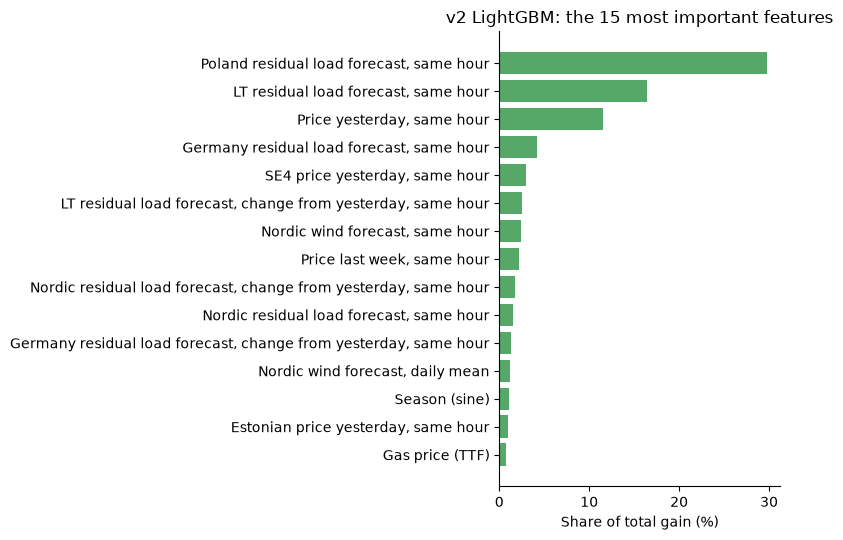

In [22]:
all_days = pd.date_range(TEST[0], last_day, freq="D")
monthly = pd.DataFrame({name: mae_by(pred, all_days, "month") for name, pred in
                        {"naive": forecasts["Naive"], "v1 ensemble": v1["Ensemble"], "v2 main": v2[V2_MAIN]}.items()})
monthly["v1 better than naive, %"] = 100 * (1 - monthly["v1 ensemble"] / monthly["naive"])
monthly["v2 better than naive, %"] = 100 * (1 - monthly["v2 main"] / monthly["naive"])
display(monthly.round(1))

fig, ax = plt.subplots(figsize=(8, 5.5))
model_imp, _ = fit_lgb("v2", TEST[1], V2_PARAMS, V2_TREES[HALF_LIVES[-1]], HALF_LIVES[-1])
imp = pd.Series(model_imp.booster_.feature_importance("gain"), index=feats2).sort_values(ascending=False)
top2 = (100 * imp / imp.sum()).head(15)
ax.barh([readable(n) for n in top2.index[::-1]], top2.to_numpy()[::-1], color="#55a868")
ax.set_xlabel("Share of total gain (%)")
ax.set_title("v2 LightGBM: the 15 most important features")
fig.tight_layout()
save(fig, "q3_v2_feature_importance")
plt.show()

### 8.4 Do the Lasso convergence warnings matter?

In [23]:
def convergence_check(n_days=12):
    # Do the Lasso convergence warnings matter? The Lasso models of n_days random test days are re-fitted with ten
    # times more iterations (10,000 instead of 1,000) and their forecasts compared. lasso_aic() calls lasso_path by
    # name, so rebinding the name for the check leaves the model code, and the keys of the stored forecasts,
    # unchanged; the safeguard counts of section 5 are restored afterwards. Variables stay inside the function.
    global lasso_path
    rng = np.random.default_rng(SEED)
    sample = pd.DatetimeIndex(sorted(rng.choice(pd.date_range(*TEST, freq="D"), size=n_days, replace=False)))
    default_path, clips_before, rows = lasso_path, dict(CLIPS), []
    try:
        for label, (design, windows, share) in [("v1 Lasso", (MAIN, LASSO_WINDOWS, None)),
                                                ("v2 Lasso", LASSO_CONFIGS[LASSO_CHOICE])]:
            for day in sample:
                days, last_train_day = pd.DatetimeIndex([day]), day - pd.Timedelta(days=1)
                preds, warned = {}, {}
                for iterations in (1_000, 10_000):
                    lasso_path = partial(default_path, max_iter=iterations)
                    with count_warnings() as counts:
                        preds[iterations] = lasso_block(design, days, last_train_day, windows=windows, max_df_share=share)
                    warned[iterations] = sum(counts.values())
                diff = (preds[10_000] - preds[1_000]).abs().to_numpy()
                rows.append({"model": label, "day": day.date(), "warnings, 1,000 iterations": warned[1_000],
                             "warnings, 10,000 iterations": warned[10_000],
                             "largest change, €/MWh": np.nanmax(diff), "mean change, €/MWh": np.nanmean(diff)})
    finally:
        lasso_path = default_path
        CLIPS.update(clips_before)
    return pd.DataFrame(rows)


convergence = convergence_check()
display(convergence.groupby("model").agg(**{
    "days checked": ("day", "count"),
    "warnings per day, 1,000 iterations": ("warnings, 1,000 iterations", "mean"),
    "warnings per day, 10,000 iterations": ("warnings, 10,000 iterations", "mean"),
    "largest change, €/MWh": ("largest change, €/MWh", "max"),
    "mean change, €/MWh": ("mean change, €/MWh", "mean")}).round(4))
convergence.round(4)

,days checked,"warnings per day, 1,000 iterations","warnings per day, 10,000 iterations","largest change, €/MWh","mean change, €/MWh"
model,,,,,
v1 Lasso,12,51.00,0.0000,0.1802,0.0063
v2 Lasso,12,167.75,0.5833,0.0000,0.0000


,model,day,"warnings, 1,000 iterations","warnings, 10,000 iterations","largest change, €/MWh","mean change, €/MWh"
0,v1 Lasso,2026-01-21,50,0,0.1270,0.0073
1,v1 Lasso,2026-01-23,46,0,0.1478,0.0131
2,v1 Lasso,2026-02-18,45,0,0.0274,0.0039
3,v1 Lasso,2026-04-13,33,0,0.0332,0.0032
4,v1 Lasso,2026-04-14,37,0,0.0090,0.0007
5,v1 Lasso,2026-05-08,40,0,0.1026,0.0090
6,v1 Lasso,2026-06-03,46,0,0.1500,0.0067
7,v1 Lasso,2026-06-16,48,0,0.0115,0.0009
8,v1 Lasso,2026-06-30,60,0,0.0501,0.0041
9,v1 Lasso,2026-07-23,68,0,0.0147,0.0011


## 9. Forecasting the uncertainty: 80% prediction intervals

  intervals: stored result computed 2026-10-07 11:16 at commit b85cc51 in 6.2 minutes; warnings: 48 x IterationLimitWarning (Maximum number of iterations (5000) reached.)


coverage of the 80% interval, %  \
test (Jan–Aug 2026, indicative)   QRA                                    74.10   
                                  past errors                            76.26   
fresh (01 Sep–26 Sep 2026, clean) QRA                                    67.74   
                                  past errors                            67.09   

                                               mean width, €/MWh  pinball loss  
test (Jan–Aug 2026, indicative)   QRA                      66.74          7.72  
                                  past errors              67.37          7.82  
fresh (01 Sep–26 Sep 2026, clean) QRA                      83.91         10.63  
                                  past errors              78.65         10.57

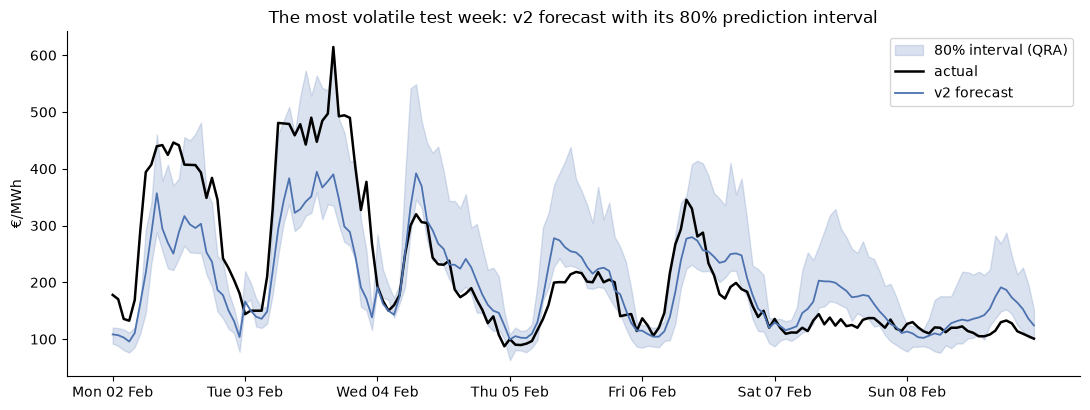

In [24]:
from statsmodels.regression.quantile_regression import QuantReg

QUANTILES = [0.1, 0.5, 0.9]
interval_days = pd.date_range(TEST[0], last_day, freq="D")
L_np, G_np = v2["Lasso"].reindex(DAYS).to_numpy(), v2["LightGBM"].reindex(DAYS).to_numpy()
E_np = v2[V2_MAIN].reindex(DAYS).to_numpy()
R_np = REAL.to_numpy()


def interval_forecasts(window=56):
    # QRA and the past-error benchmark for every day in interval_days, from the previous `window` days only.
    qra = {q: np.full((len(interval_days), 24), np.nan) for q in QUANTILES}
    bench = {q: np.full((len(interval_days), 24), np.nan) for q in QUANTILES}
    for i, day in enumerate(interval_days):
        t = DAY_POS[day]
        past = slice(t - window, t)
        for h in range(24):
            y, l, g, e = P_NP[past, h], L_np[past, h], G_np[past, h], E_np[past, h]
            ok = np.isfinite(y) & np.isfinite(l) & np.isfinite(g) & R_np[past, h]
            if ok.sum() < 30 or not np.isfinite([L_np[t, h], G_np[t, h]]).all():
                continue
            X = np.column_stack([np.ones(ok.sum()), l[ok], g[ok]])
            x_new = np.array([1.0, L_np[t, h], G_np[t, h]])
            values = sorted(float(QuantReg(y[ok], X).fit(q=q, max_iter=5000).params @ x_new) for q in QUANTILES)
            past_errors = y[ok] - e[ok]
            for q, v in zip(QUANTILES, values):
                qra[q][i, h] = v
                bench[q][i, h] = E_np[t, h] + (np.quantile(past_errors, q) if q != 0.5 else 0.0)
    to_frame = lambda arr: pd.DataFrame(arr, index=interval_days, columns=range(24))
    return ({q: to_frame(a) for q, a in qra.items()}, {q: to_frame(a) for q, a in bench.items()})


QRA, BENCH = cached("intervals", interval_forecasts, L_np, G_np, E_np, R_np, interval_days)


def interval_scores(quantiles, days):
    real = REAL.reindex(days)
    y = P.reindex(days).where(real)
    low, high = quantiles[0.1].reindex(days), quantiles[0.9].reindex(days)
    pinball = np.nanmean([np.nanmean(np.maximum(q * (y - quantiles[q].reindex(days)),
                                                (q - 1) * (y - quantiles[q].reindex(days))).to_numpy())
                          for q in QUANTILES])
    inside = ((y >= low) & (y <= high)).where(y.notna() & low.notna())
    return {"coverage of the 80% interval, %": 100 * np.nanmean(inside.to_numpy(dtype=float)),
            "mean width, €/MWh": np.nanmean((high - low).where(real).to_numpy()), "pinball loss": pinball}


interval_table = pd.DataFrame({(label, method): interval_scores(qs, days)
                               for label, days in periods.items()
                               for method, qs in [("QRA", QRA), ("past errors", BENCH)]}).T
display(interval_table.round(2))

fig, ax = plt.subplots(figsize=(11, 4.2))
real_week = REAL.reindex(week_days)
flat_week = lambda table: table.reindex(week_days).where(real_week).to_numpy().ravel()
x = np.arange(24 * len(week_days))
ax.fill_between(x, flat_week(QRA[0.1]), flat_week(QRA[0.9]), color="#4c72b0", alpha=0.2, label="80% interval (QRA)")
ax.plot(x, flat_week(P), color="black", lw=1.8, label="actual")
ax.plot(x, flat_week(v2[V2_MAIN]), color="#4c72b0", lw=1.3, label="v2 forecast")
ax.set_xticks(range(0, 24 * len(week_days), 24), [d.strftime("%a %d %b") for d in week_days])
ax.set_ylabel("€/MWh")
ax.set_title("The most volatile test week: v2 forecast with its 80% prediction interval")
ax.legend()
fig.tight_layout()
save(fig, "q3_v2_interval_week")
plt.show()

## 10. How close is the forecast in practice?

In [25]:
# How often is the v2 forecast close to the actual price?
rows = {}
for label, days in periods.items():
    real = REAL.reindex(days)
    pred, actual = v2[V2_MAIN].reindex(days).where(real), P.reindex(days).where(real)
    abs_err = (pred - actual).abs().to_numpy().ravel()
    abs_err = abs_err[np.isfinite(abs_err)]
    daily_pred, daily_actual = pred.mean(axis=1), actual.mean(axis=1)
    yesterday = P.shift(1).reindex(days).mean(axis=1)                  # yesterday's actual daily average
    right_direction = np.sign(daily_pred - yesterday) == np.sign(daily_actual - yesterday)
    rows[label] = {
        "hours within ±10 €/MWh, %": 100 * (abs_err <= 10).mean(),
        "hours within ±20 €/MWh, %": 100 * (abs_err <= 20).mean(),
        "hours within ±50 €/MWh, %": 100 * (abs_err <= 50).mean(),
        "median hourly error, €/MWh": np.median(abs_err),
        "daily average: mean absolute error, €/MWh": (daily_pred - daily_actual).abs().mean(),
        "daily average up/down vs yesterday right, %": 100 * right_direction.mean(),
        "most expensive hour right (±1 h), %": 100 * ((pred.idxmax(axis=1) - actual.idxmax(axis=1)).abs() <= 1).mean(),
        "cheapest hour right (±1 h), %": 100 * ((pred.idxmin(axis=1) - actual.idxmin(axis=1)).abs() <= 1).mean(),
    }
pd.DataFrame(rows).round(1)

,"test (Jan–Aug 2026, indicative)","fresh (01 Sep–26 Sep 2026, clean)"
"hours within ±10 €/MWh, %",32.7,22.5
"hours within ±20 €/MWh, %",58.1,42.7
"hours within ±50 €/MWh, %",90.3,75.3
"median hourly error, €/MWh",16.3,24.8
"daily average: mean absolute error, €/MWh",15.2,24.3
"daily average up/down vs yesterday right, %",86.8,88.5
"most expensive hour right (±1 h), %",74.1,50.0
"cheapest hour right (±1 h), %",48.6,30.8


## 11. What the forecast is worth: a battery test

In [26]:
from scipy.optimize import linprog

POWER_MW, ENERGY_MWH, ROUND_TRIP = 1.0, 2.0, 0.88
ETA = np.sqrt(ROUND_TRIP)  # the same loss when charging and when discharging


def battery_plan(prices, available):
    # The most profitable plan for one day at the given prices: start and end the day empty, at most one full
    # cycle, charging plus discharging never above the power rating. Returns MW sold per hour (negative = buying).
    n = len(prices)
    p = np.where(available, np.nan_to_num(prices), 0.0)
    cap = np.where(available, POWER_MW, 0.0)
    cost = np.concatenate([p, -p, np.zeros(n)])        # variables: charge c, discharge d, state of charge s
    A_eq, b_eq = np.zeros((n + 1, 3 * n)), np.zeros(n + 1)
    for h in range(n):
        A_eq[h, 2 * n + h] = 1.0                        # s_h
        if h > 0:
            A_eq[h, 2 * n + h - 1] = -1.0               # - s_(h-1)
        A_eq[h, h], A_eq[h, n + h] = -ETA, 1.0 / ETA    # - eta * c_h + d_h / eta
    A_eq[n, 3 * n - 1] = 1.0                            # empty at the end of the day
    A_ub = np.zeros((n + 1, 3 * n))
    A_ub[0, n:2 * n] = 1.0 / ETA                        # at most one full cycle of stored energy a day
    for h in range(n):
        A_ub[h + 1, h] = A_ub[h + 1, n + h] = 1.0       # charge + discharge <= power rating
    b_ub = np.concatenate([[ENERGY_MWH], cap])
    bounds = [(0, c) for c in cap] * 2 + [(0, ENERGY_MWH)] * n
    res = linprog(cost, A_ub=A_ub, b_ub=b_ub, A_eq=A_eq, b_eq=b_eq, bounds=bounds, method="highs")
    return res.x[n:2 * n] - res.x[:n]


strategies = {"perfect foresight": P, "naive": forecasts["Naive"], "v1 ensemble (fixed in advance)": v1["Ensemble"],
              "v2 main": v2[V2_MAIN]}
battery_days = pd.date_range(TEST[0], last_day, freq="D")
profit = pd.DataFrame(index=battery_days, columns=list(strategies), dtype=float)
for day in battery_days:
    actual = P.loc[day].to_numpy()
    real = REAL.loc[day].to_numpy() & np.isfinite(actual)
    for name, table in strategies.items():
        forecast = table.loc[day].to_numpy()
        ok = real & np.isfinite(forecast)
        profit.loc[day, name] = float(np.sum(np.where(ok, actual, 0.0) * battery_plan(forecast, ok)))

rows = {}
for label, days in periods.items():
    total = profit.reindex(days).sum()
    for name in strategies:
        rows[(label, name)] = {"profit, € per MW": total[name],
                               "share of perfect foresight, %": 100 * total[name] / total["perfect foresight"],
                               "per MW and year, €": total[name] * 365 / len(days)}
battery = pd.DataFrame(rows).T
display(battery.round(1))

profit, € per MW  \
test (Jan–Aug 2026, indicative)   perfect foresight                        56113.5   
                                  naive                                    43554.9   
                                  v1 ensemble (fixed in advance)           49968.6   
                                  v2 main                                  50044.9   
fresh (01 Sep–26 Sep 2026, clean) perfect foresight                         6038.3   
                                  naive                                     3643.2   
                                  v1 ensemble (fixed in advance)            5136.0   
                                  v2 main                                   5096.6   

                                                                  share of perfect foresight, %  \
test (Jan–Aug 2026, indicative)   perfect foresight                                       100.0   
                                  naive                                                    77.6   
                                  v1 ensemble (fixed in advance)                           89.0   
                                  v2 main                                                  89.2   
fresh (01 Sep–26 Sep 2026, clean) perfect foresight                                       100.0   
                                  naive                                                    60.3   
                                  v1 ensemble (fixed in advance)                           85.1   
                                  v2 main                                                  84.4   

                                                                  per MW and year, €  
test (Jan–Aug 2026, indicative)   perfect foresight                          84285.8  
                                  naive                                      65422.0  
                                  v1 ensemble (fixed in advance)             75055.7  
                                  v2 main                                    75170.3  
fresh (01 Sep–26 Sep 2026, clean) perfect foresight                          84767.9  
                                  naive                                      51144.9  
                                  v1 ensemble (fixed in advance)             72101.6  
                                  v2 main                                    71548.8

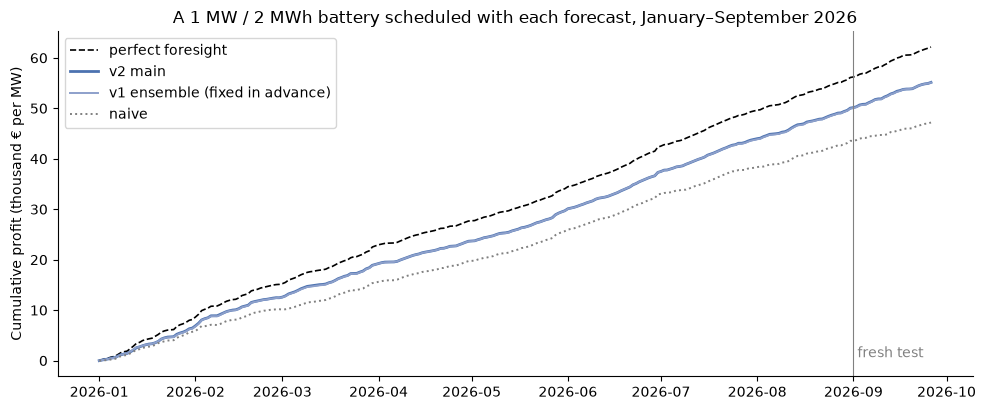

In [27]:
fig, ax = plt.subplots(figsize=(10, 4.2))
cumulative = profit.cumsum() / 1000
for name, style in [("perfect foresight", dict(color="black", ls="--", lw=1.2)),
                    ("v2 main", dict(color="#4c72b0", lw=2)),
                    ("v1 ensemble (fixed in advance)", dict(color="#8da0cb", lw=1.4)),
                    ("naive", dict(color="grey", ls=":", lw=1.4))]:
    ax.plot(cumulative.index, cumulative[name], label=name, **style)
if HAS_FRESH:
    ax.axvline(FRESH[0], color="grey", lw=0.8)
    ax.text(FRESH[0], 0, " fresh test", color="grey", va="bottom")
ax.set_ylabel("Cumulative profit (thousand € per MW)")
ax.set_title("A 1 MW / 2 MWh battery scheduled with each forecast, January–September 2026")
ax.legend()
fig.tight_layout()
save(fig, "q3_battery_value")
plt.show()

## 12. Summary of the improvements

In [28]:
rows = [["Validation choice, Lasso", LASSO_CHOICE], ["Validation choice, LightGBM", LGB_CHOICE]]
for label, days in periods.items():
    table = compare(days)
    t = tests.loc[(label, "v2 main vs v1 ensemble")]
    rows.append([f"{label}: MAE v2 main vs v1 ensemble",
                 f"{table.loc['v2 ensemble, hour weights (v2 main)', 'MAE, €/MWh']:.2f} vs "
                 f"{table.loc['v1 ensemble (fixed in advance)', 'MAE, €/MWh']:.2f} €/MWh "
                 f"({change(table.loc['v2 ensemble, hour weights (v2 main)', 'MAE, €/MWh'], table.loc['v1 ensemble (fixed in advance)', 'MAE, €/MWh'])}; "
                 f"DM {fmt_p(t['DM p'])}, GW {fmt_p(t['GW p'])})"])
    rows.append([f"{label}: MAE relative to the weekly naive, v1 / v2",
                 f"{table.loc['v1 ensemble (fixed in advance)', 'MAE relative to weekly naive']:.2f} / "
                 f"{table.loc['v2 ensemble, hour weights (v2 main)', 'MAE relative to weekly naive']:.2f}"])
    qra = interval_table.loc[(label, "QRA")]
    rows.append([f"{label}: 80% interval (QRA)",
                 f"covers {qra['coverage of the 80% interval, %']:.0f}% of hours, mean width {qra['mean width, €/MWh']:.0f} €/MWh"])
for label in periods:
    share = battery.loc[label, "share of perfect foresight, %"]
    rows.append([f"{label}: battery value captured (share of perfect foresight), v1 / v2",
                 f"{share['v1 ensemble (fixed in advance)']:.0f}% / {share['v2 main']:.0f}%"])
v2_summary = pd.DataFrame(rows, columns=["finding", "estimate"])
v2_summary.to_csv(FIG / "q3_v2_summary.csv", index=False)
v2_summary

,finding,estimate
0,"Validation choice, Lasso","v2 inputs, windows 56/84/364/728"
1,"Validation choice, LightGBM","v2 inputs, averaged half-lives"
2,"test (Jan–Aug 2026, indicative): MAE v2 main v...","23.02 vs 24.77 €/MWh (7% lower; DM p < 0.001, ..."
3,"test (Jan–Aug 2026, indicative): MAE relative ...",0.49 / 0.45
4,"test (Jan–Aug 2026, indicative): 80% interval ...","covers 74% of hours, mean width 67 €/MWh"
5,"fresh (01 Sep–26 Sep 2026, clean): MAE v2 main...","32.45 vs 34.13 €/MWh (5% lower; DM p < 0.001, ..."
6,"fresh (01 Sep–26 Sep 2026, clean): MAE relativ...",0.39 / 0.37
7,"fresh (01 Sep–26 Sep 2026, clean): 80% interva...","covers 68% of hours, mean width 84 €/MWh"
8,"test (Jan–Aug 2026, indicative): battery value...",89% / 89%
9,"fresh (01 Sep–26 Sep 2026, clean): battery val...",85% / 84%
